In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from itertools import chain

In [2]:
df_inicial = pd.read_parquet('qtde_pessoas_familias_cadunico.parquet')

In [3]:
df_inicial.head()

,codigo_ibge,qtde_familias,qtde_pessoas,mes,ano,uf,municipio,sigla_uf,regiao
0,110001,4116,14076,12,2012,Rondônia,Alta Floresta D'Oeste,RO,Norte
1,110002,10775,37567,12,2012,Rondônia,Ariquemes,RO,Norte
2,110003,993,3313,12,2012,Rondônia,Cabixi,RO,Norte
3,110004,8516,29459,12,2012,Rondônia,Cacoal,RO,Norte
4,110005,2259,7918,12,2012,Rondônia,Cerejeiras,RO,Norte


In [4]:
df_qtde_por_ano = (
    df_inicial.query('''
        mes == 12
    ''')
    .melt(
        id_vars='ano',
        value_vars=['qtde_pessoas', 'qtde_familias'],
        var_name='grupo',
        value_name='qtde'
    )
    .replace({
        'qtde_pessoas': 'Pessoas',
        'qtde_familias': 'Famílias'
    })
    .assign(grupo = lambda x: pd.Categorical(
        x['grupo'], 
        categories=['Pessoas', 'Famílias'])
    )
    .groupby(['ano', 'grupo'])
    .agg('sum')
    .reset_index()
)

In [5]:
df_qtde_por_ano.head()

,ano,grupo,qtde
0,2012,Pessoas,81322507
1,2012,Famílias,25063802
2,2013,Pessoas,85057820
3,2013,Famílias,27194588
4,2014,Pessoas,88339340


In [6]:
df_qtde_por_ano.dtypes

ano         int64
grupo    category
qtde        int64
dtype: object

In [7]:
df_qtde_por_ano['qtde'] = pd.to_numeric(df_qtde_por_ano['qtde'], downcast='integer')

In [8]:
df_qtde_por_ano['qtde_1e6'] = df_qtde_por_ano['qtde'] / 1e6

In [9]:
df_qtde_por_ano.dtypes

ano            int64
grupo       category
qtde           int32
qtde_1e6     float64
dtype: object

In [10]:
anos = sorted(df_inicial['ano'].unique().tolist())
print(anos)

[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


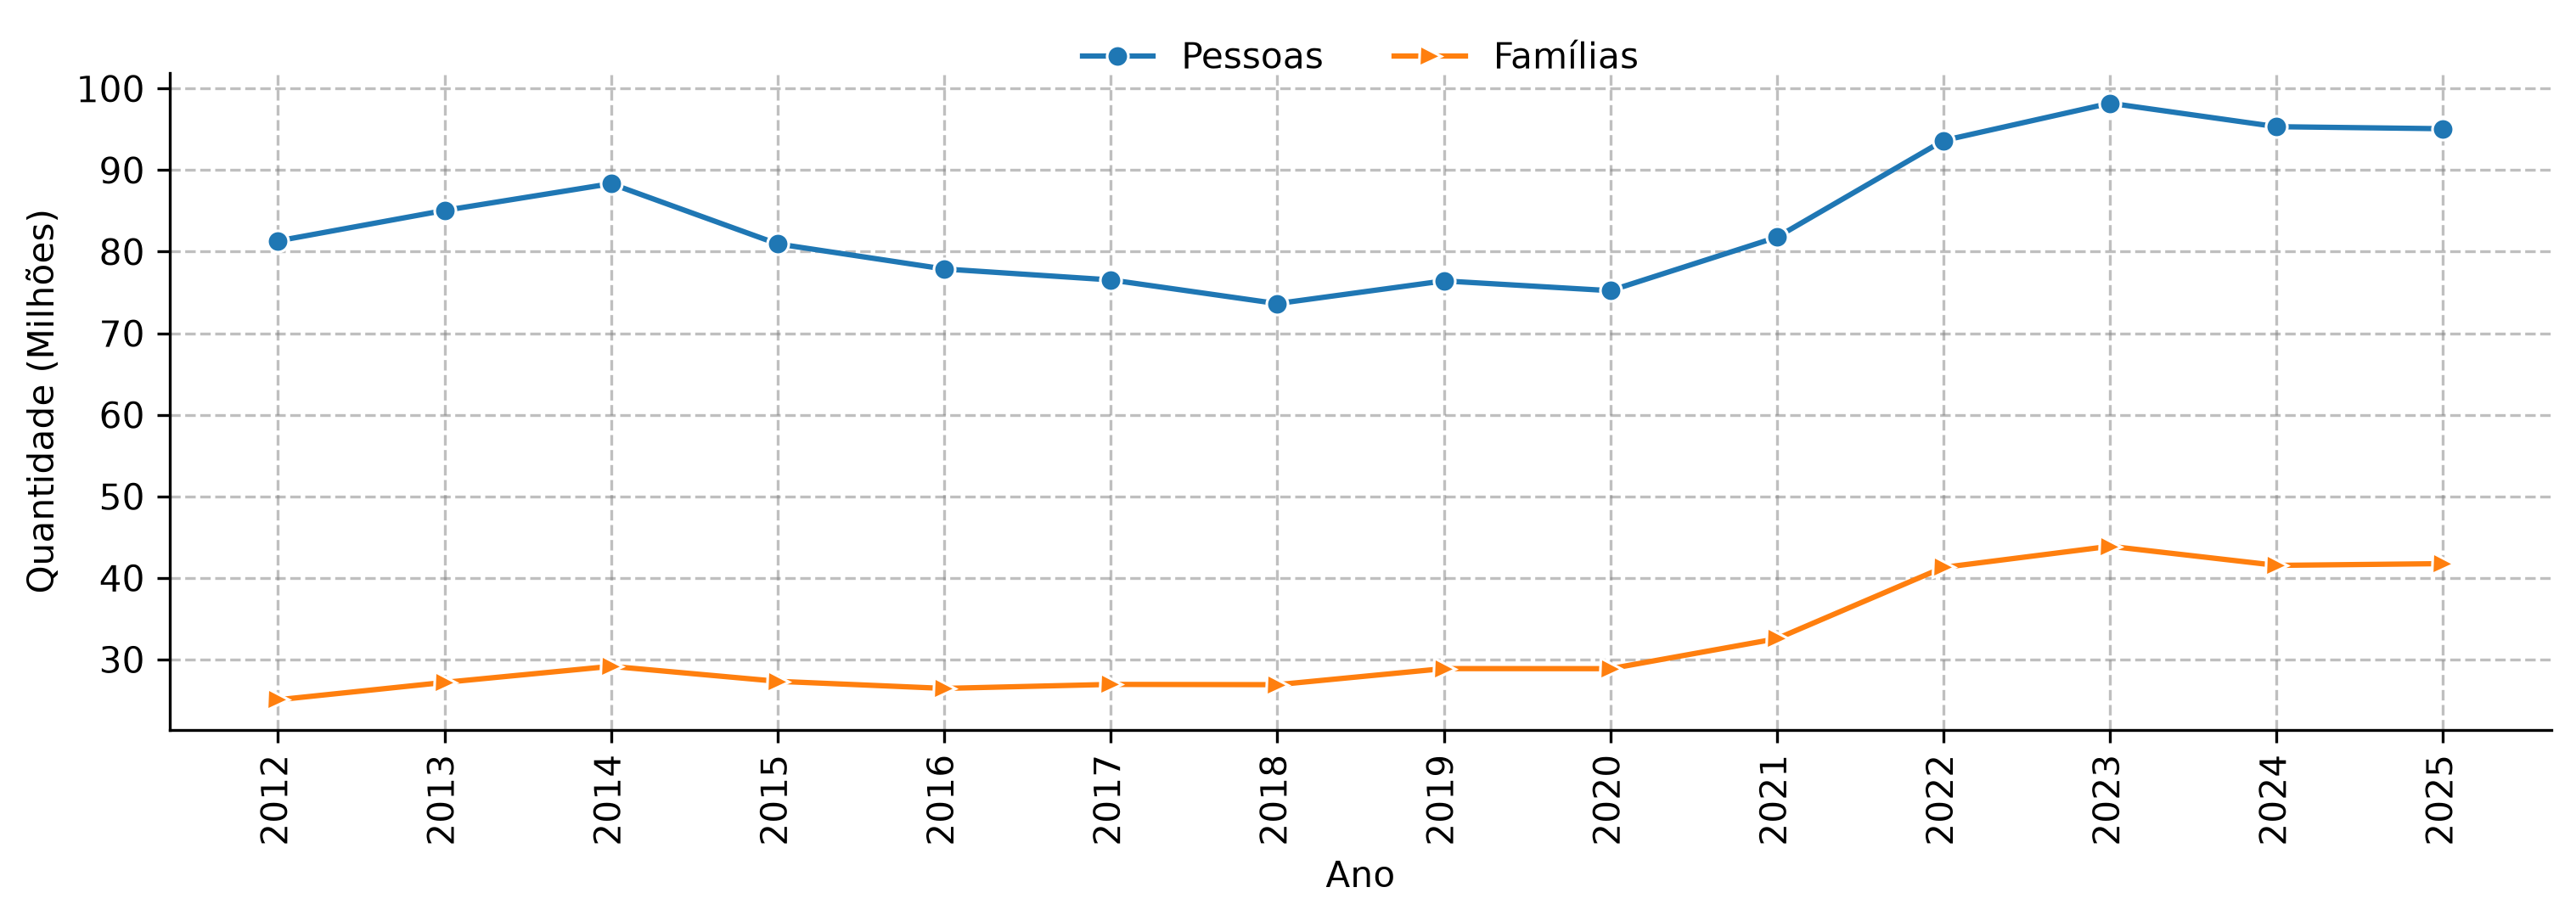

In [11]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_qtde_por_ano,
    x='ano',
    y='qtde_1e6',
    hue='grupo',
    style='grupo',
    markers=['o', '>'],
    errorbar=None,
    dashes=False,
    ax=ax
)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Quantidade (Milhões)')
ax.set_xlabel('Ano')
ax.set_xticks(anos, labels=anos, rotation=90)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=2, frameon=False)

fig.savefig('pessoas_familias_cadunico', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
df_qtde_por_ano_regiao = (
    df_inicial.query('''
        mes == 12
    ''')
    .melt(
        id_vars=['ano', 'regiao'],
        value_vars=['qtde_pessoas', 'qtde_familias'],
        var_name='grupo',
        value_name='qtde'
    )
    .replace({
        'qtde_pessoas': 'Pessoas',
        'qtde_familias': 'Famílias'
    })
    .assign(grupo = lambda x: pd.Categorical(
        x['grupo'], 
        categories=['Pessoas', 'Famílias'])
    )
    .groupby(['ano', 'grupo', 'regiao'])
    .agg('sum')
    .reset_index()
    .assign(
        qtde = lambda x: pd.to_numeric(
            x['qtde'], 
            downcast='integer'
        ),
        qtde_1e6 = lambda x: x['qtde'] / 1e6
    )
)

In [13]:
df_qtde_por_ano_regiao.head()

,ano,grupo,regiao,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,5378848,5.378848
1,2012,Pessoas,Nordeste,34445665,34.445665
2,2012,Pessoas,Norte,8612913,8.612913
3,2012,Pessoas,Sudeste,24492487,24.492487
4,2012,Pessoas,Sul,8392594,8.392594


In [14]:
df_qtde_por_ano_regiao.dtypes

ano            int64
grupo       category
regiao           str
qtde           int32
qtde_1e6     float64
dtype: object

Centro-oeste
<class 'pandas.DataFrame'>


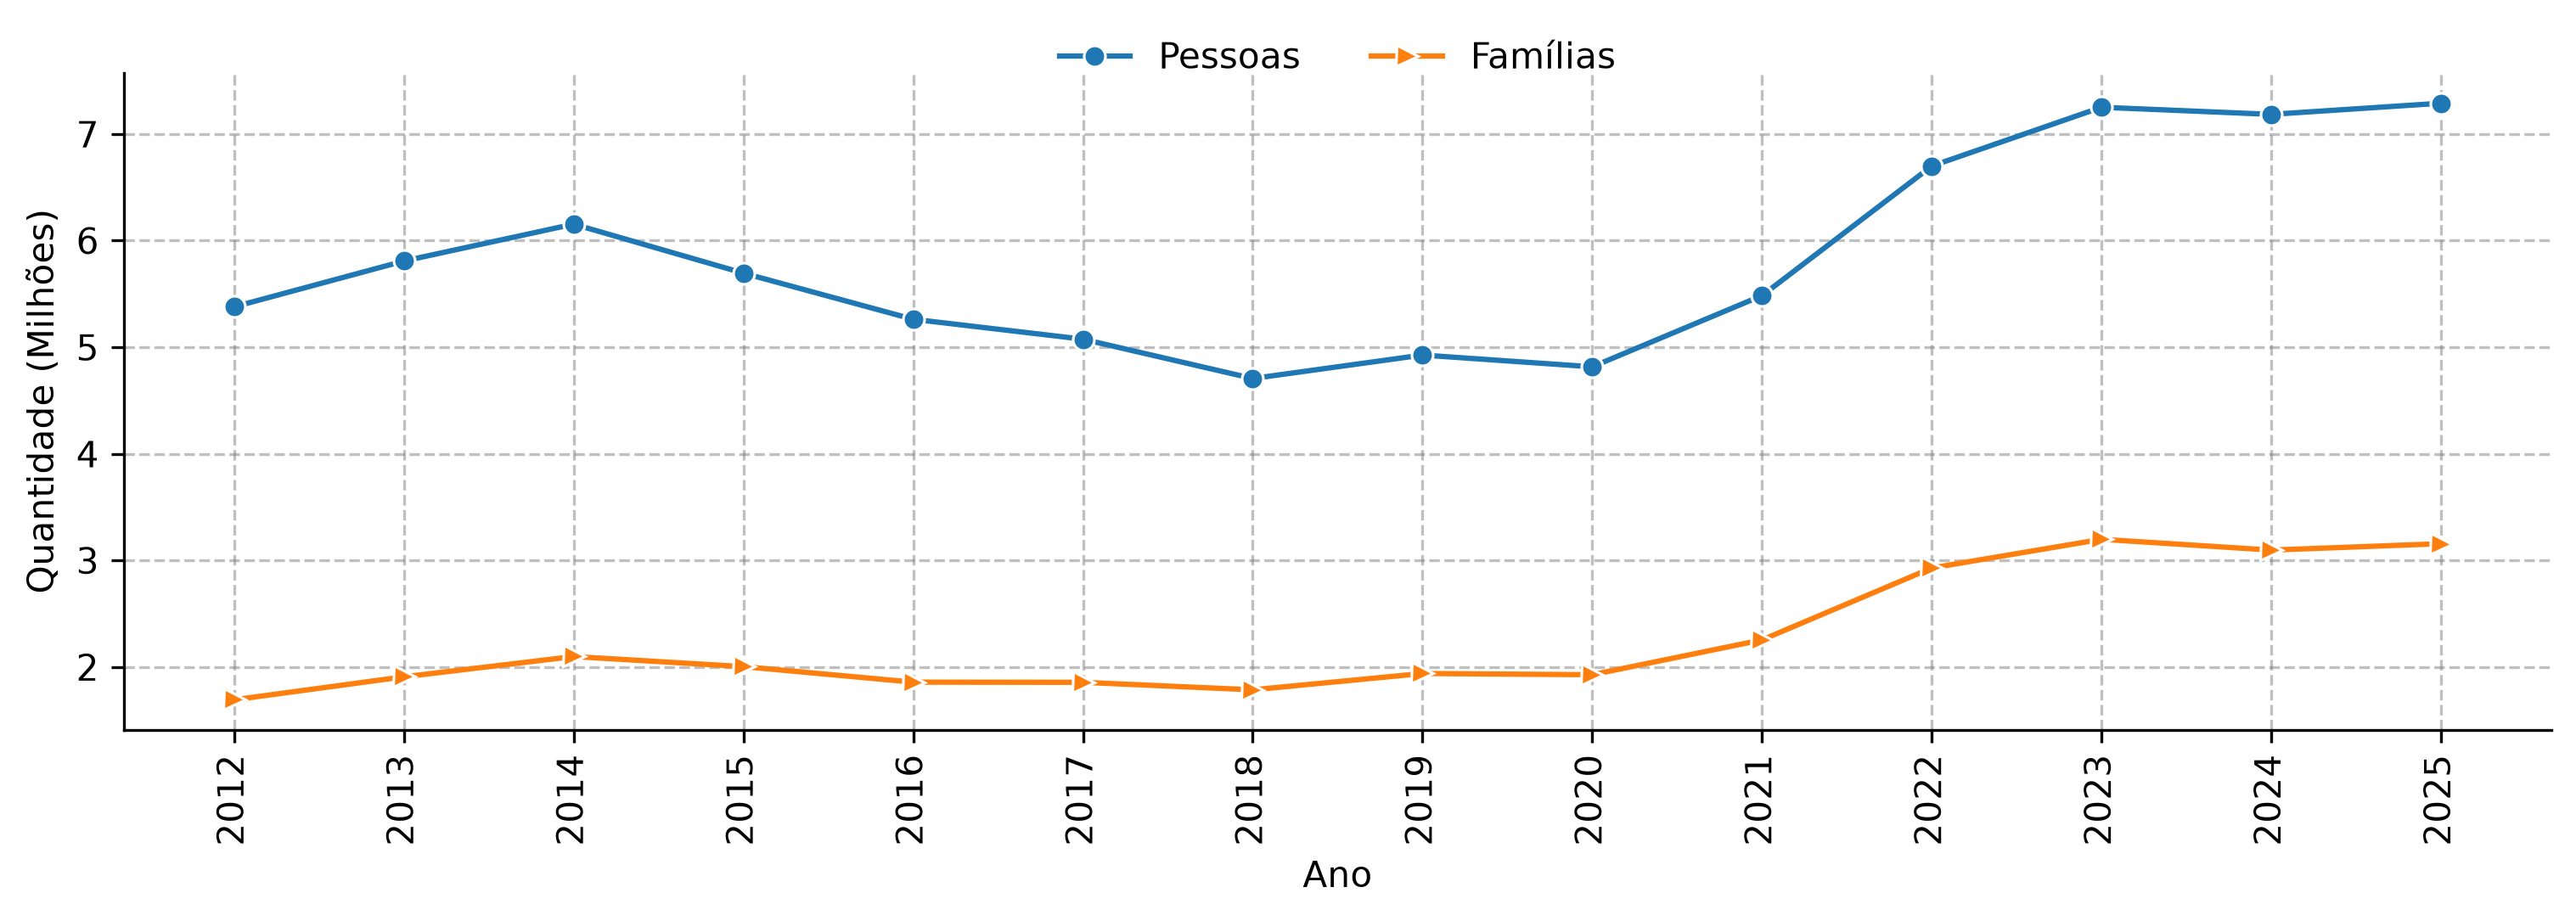

Nordeste
<class 'pandas.DataFrame'>


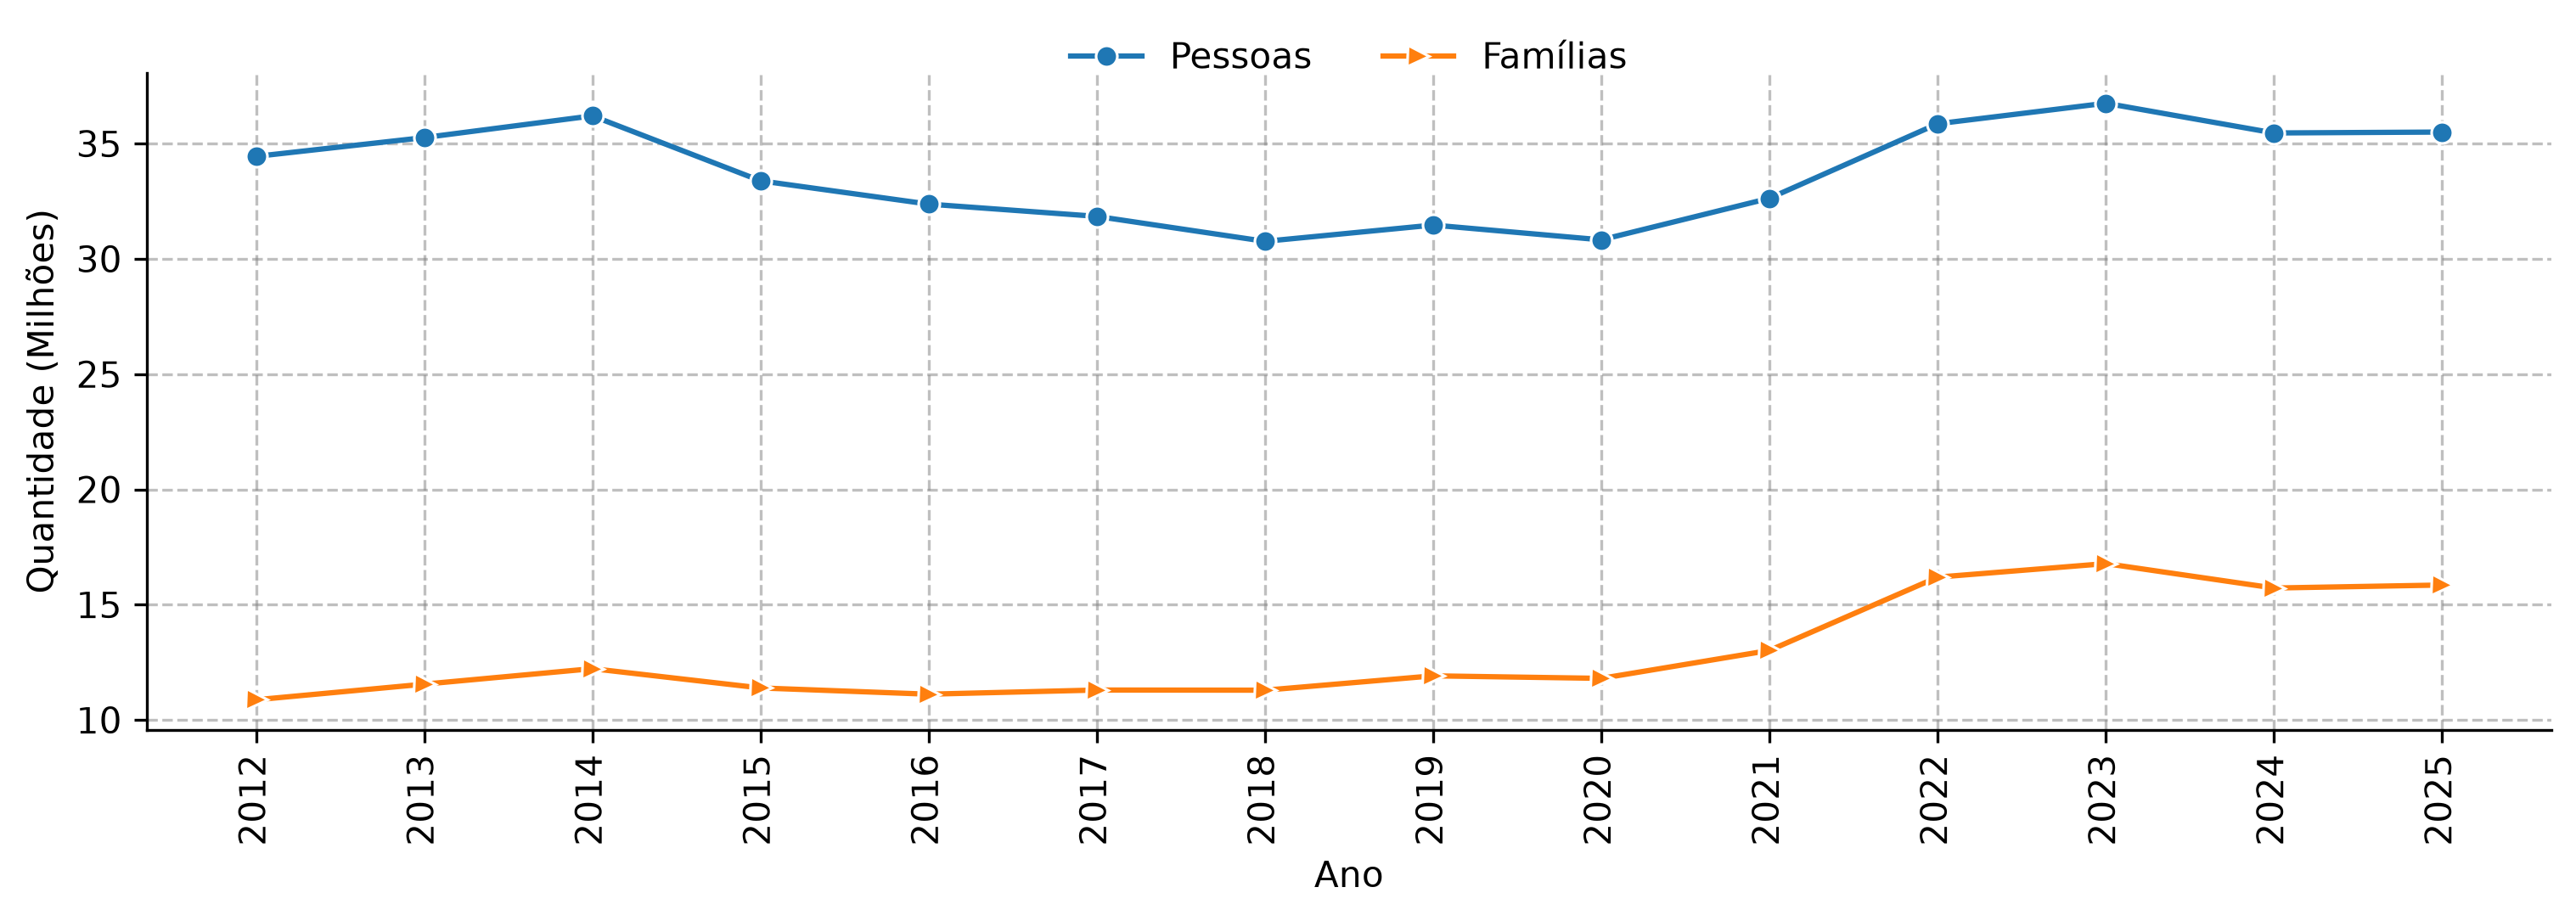

Norte
<class 'pandas.DataFrame'>


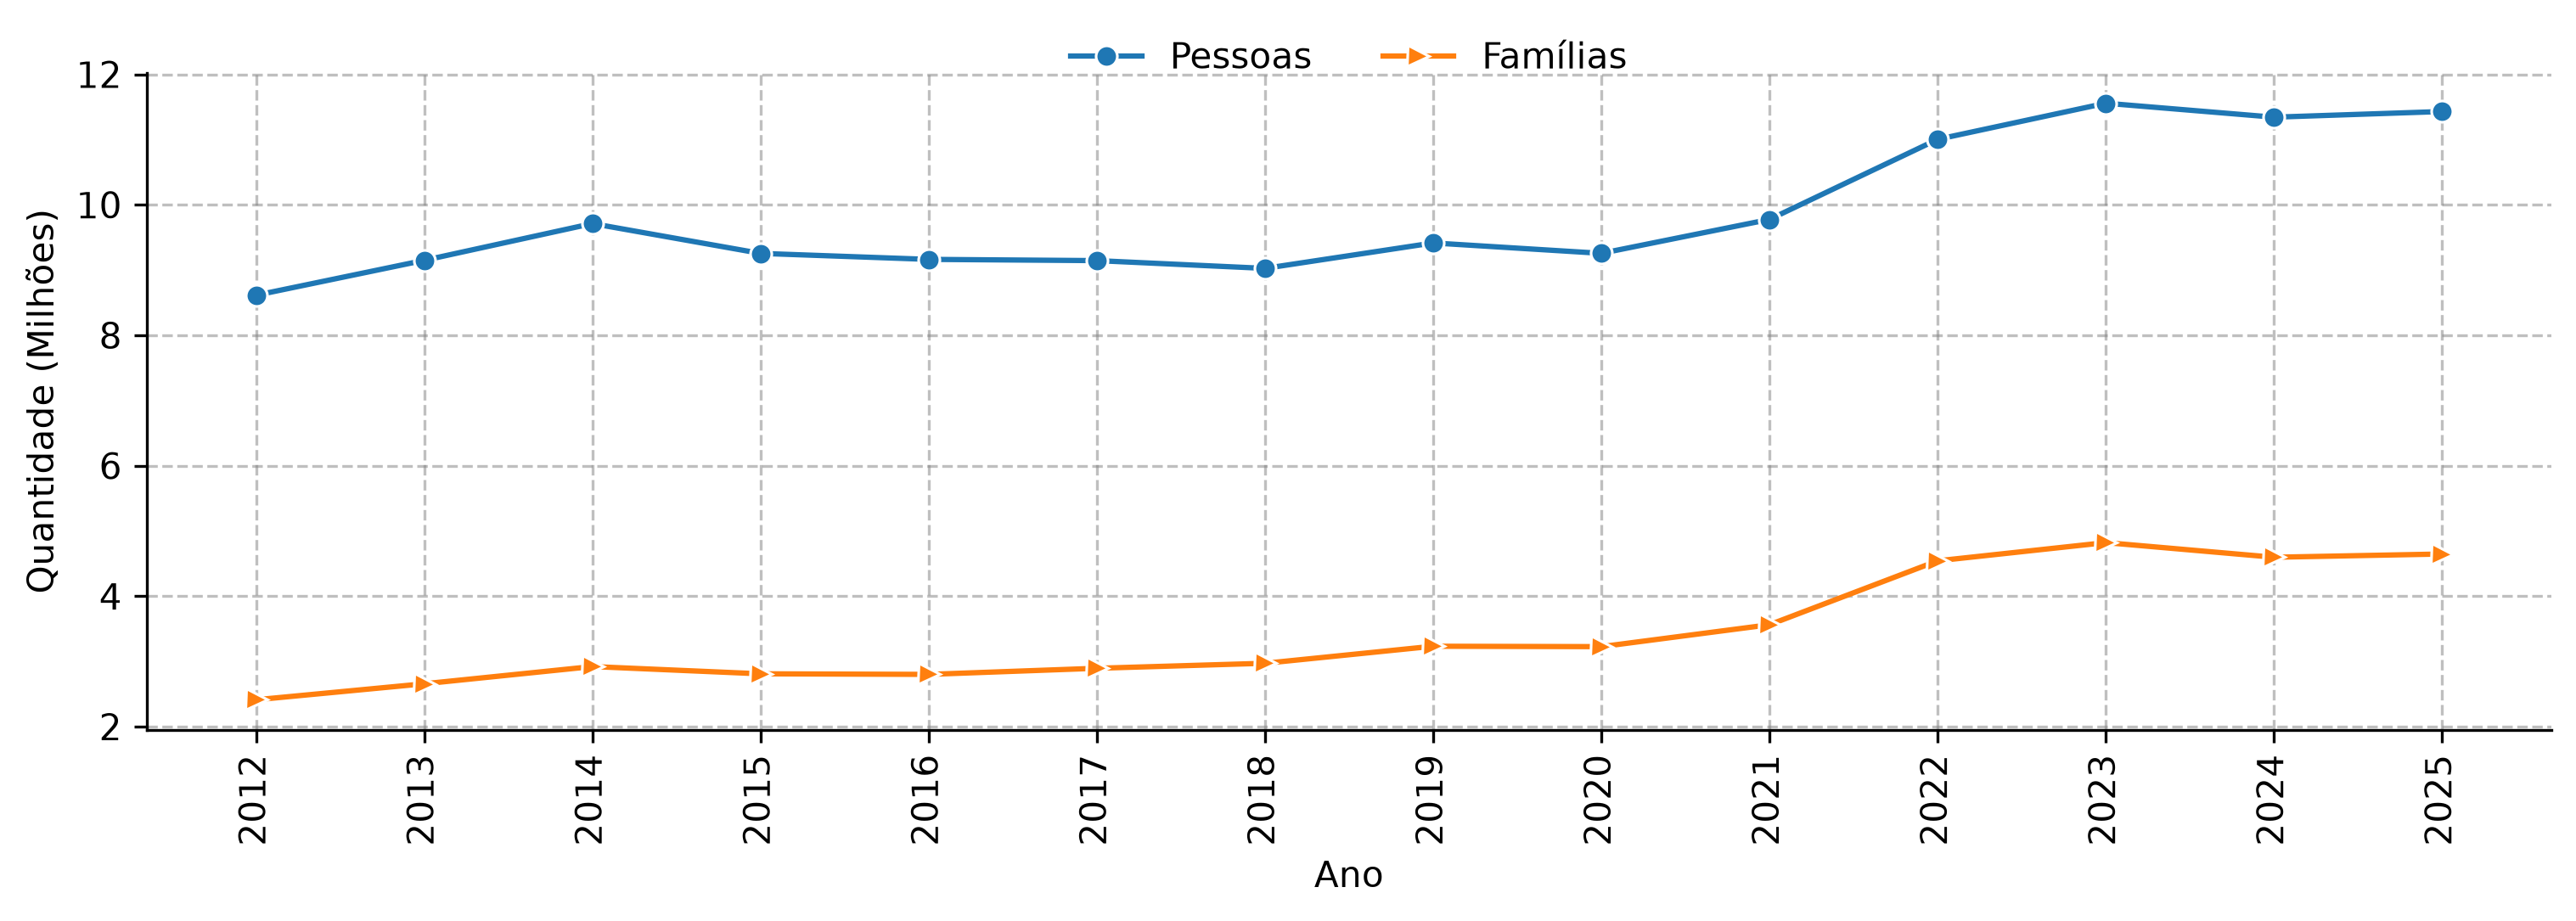

Sudeste
<class 'pandas.DataFrame'>


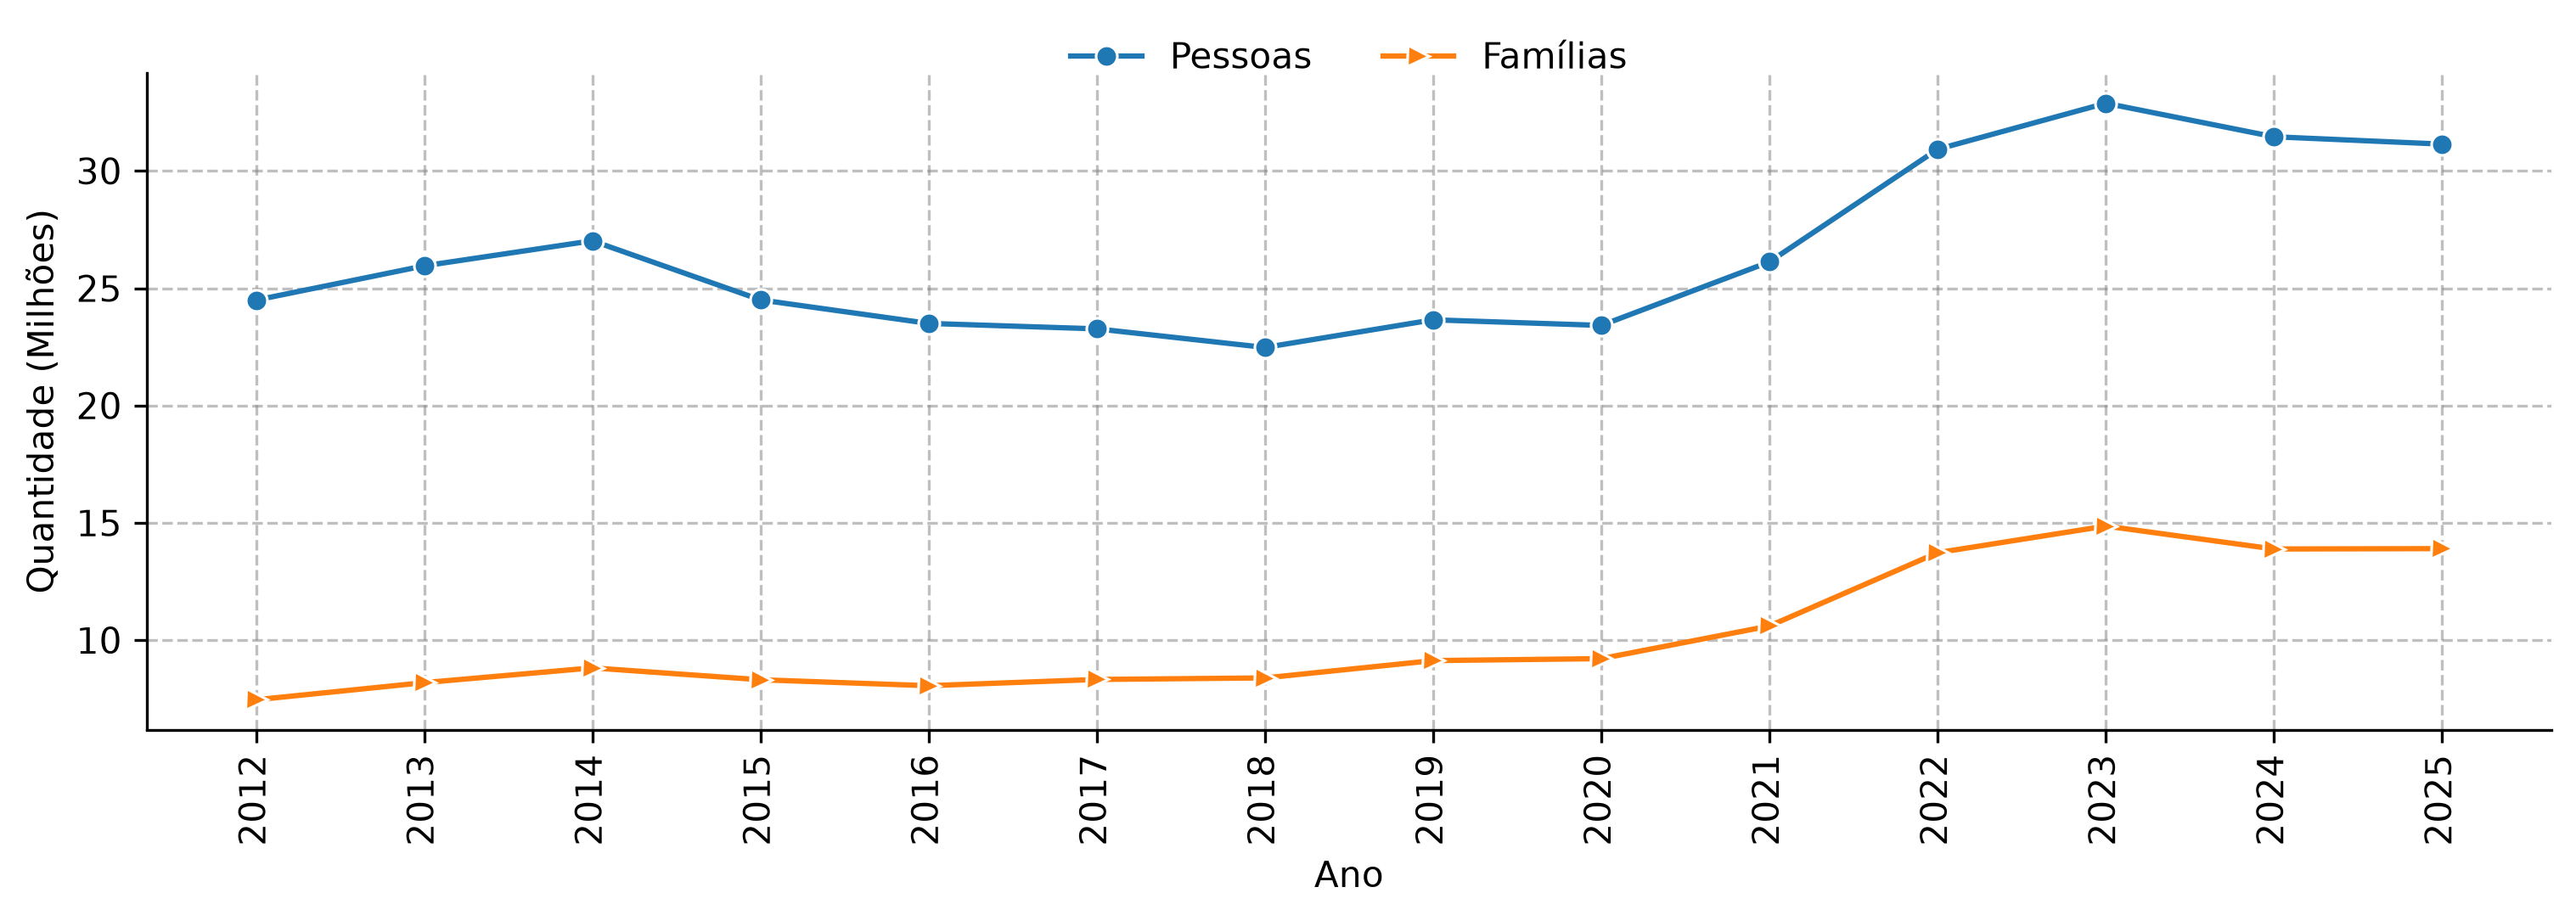

Sul
<class 'pandas.DataFrame'>


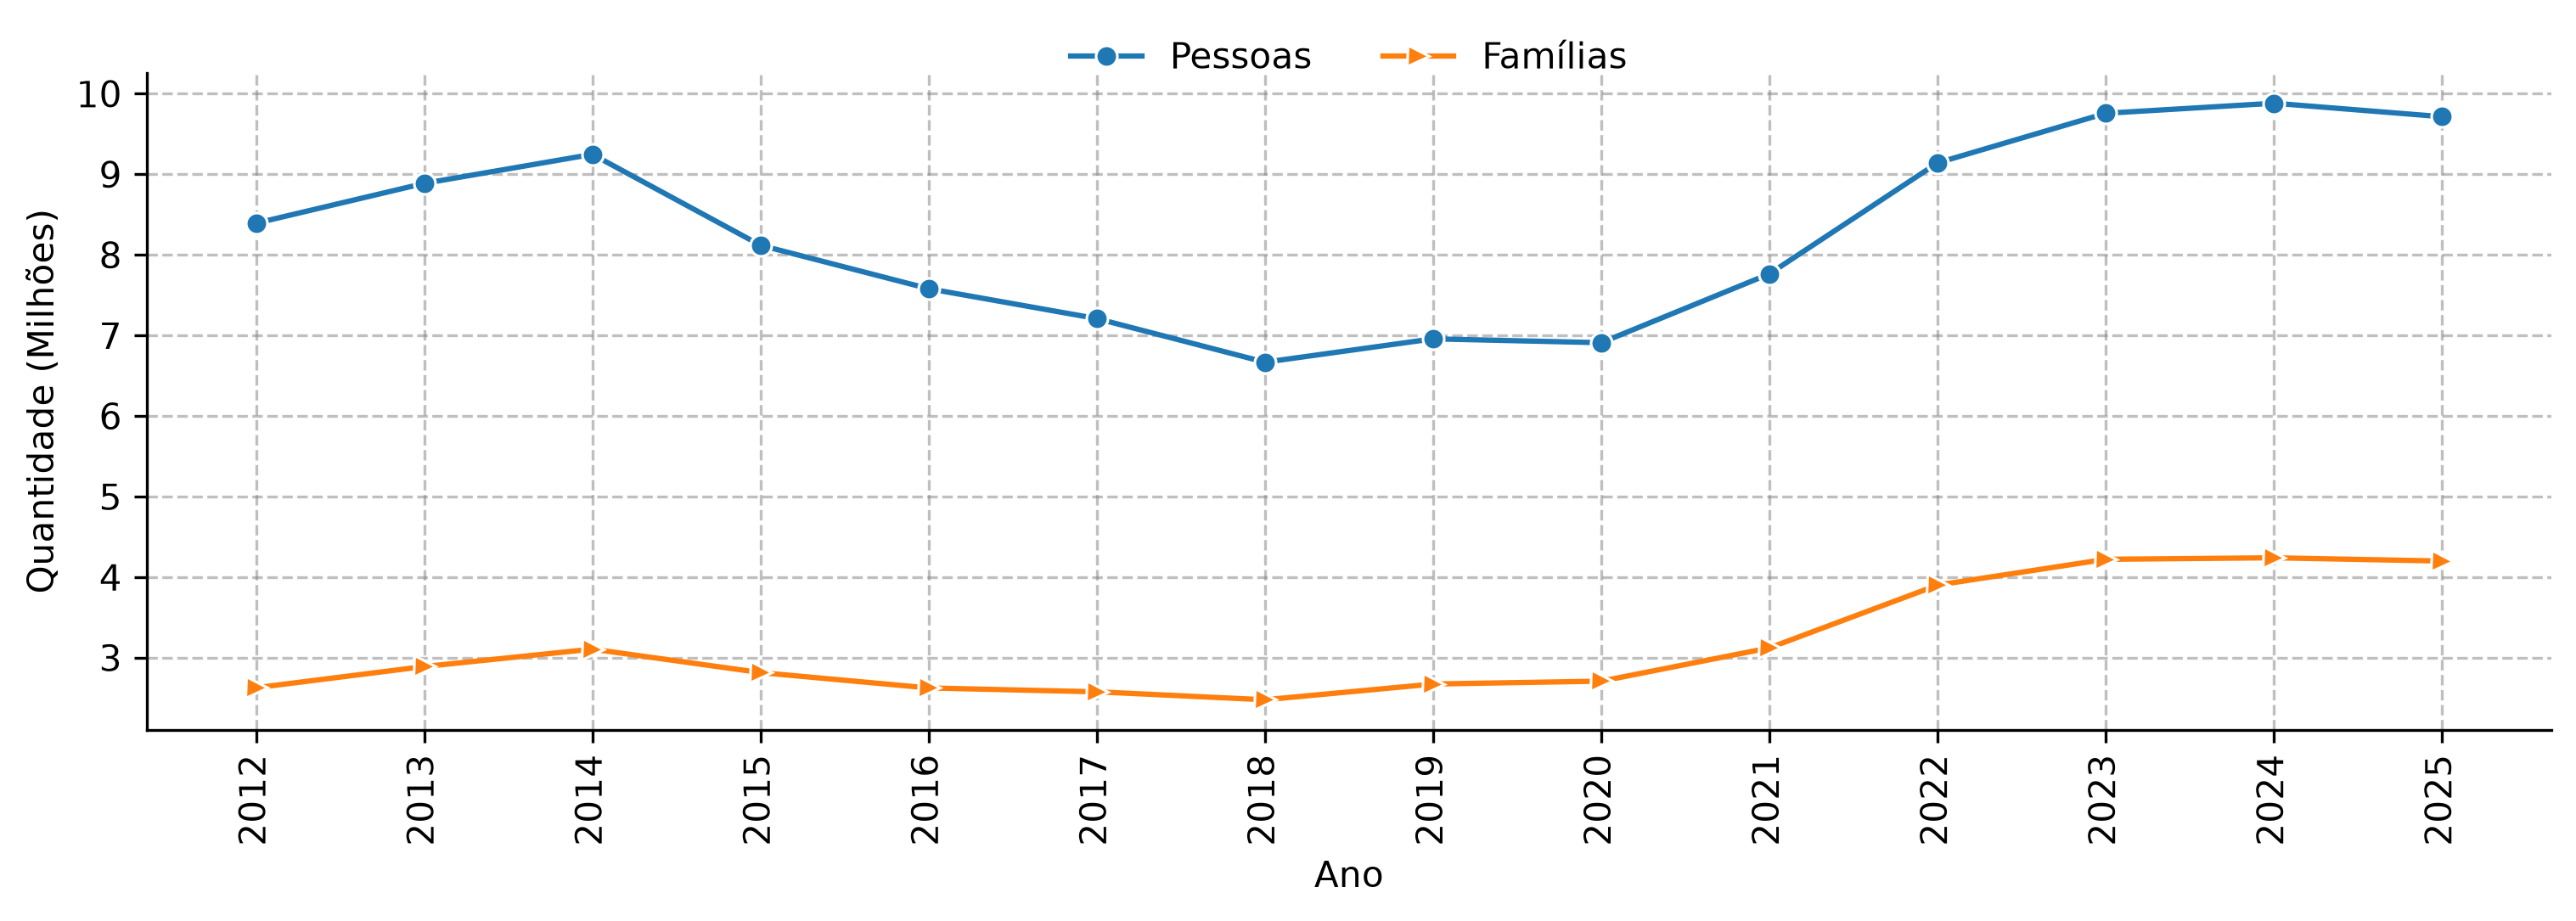

In [15]:
for (regiao, df_por_regiao) in df_qtde_por_ano_regiao.groupby('regiao'):
    print(regiao)
    print(type(df_por_regiao))

    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df_por_regiao,
        x='ano',
        y='qtde_1e6',
        hue='grupo',
        style='grupo',
        markers=['o', '>'],
        errorbar=None,
        dashes=False,
        ax=ax
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Quantidade (Milhões)')
    ax.set_xlabel('Ano')
    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=2, frameon=False)

    fig.savefig(f'pessoas_familias_cadunico_{regiao.lower()}', dpi=300, bbox_inches='tight')
    plt.show()

In [16]:
df_qtde_por_ano_regiao_uf = (
    df_inicial.query('''
        mes == 12
    ''')
    .melt(
        id_vars=['ano', 'regiao', 'sigla_uf', 'uf'],
        value_vars=['qtde_pessoas', 'qtde_familias'],
        var_name='grupo',
        value_name='qtde'
    )
    .replace({
        'qtde_pessoas': 'Pessoas',
        'qtde_familias': 'Famílias'
    })
    .assign(grupo = lambda x: pd.Categorical(
        x['grupo'], 
        categories=['Pessoas', 'Famílias'])
    )
    .groupby(['ano', 'grupo', 'regiao', 'sigla_uf', 'uf'])
    .agg('sum')
    .reset_index()
    .assign(
        qtde = lambda x: pd.to_numeric(
            x['qtde'], 
            downcast='integer'
        ),
        qtde_1e6 = lambda x: x['qtde'] / 1e6
    )
)

In [17]:
df_qtde_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,uf,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,DF,Distrito Federal,804338,0.804338
1,2012,Pessoas,Centro-oeste,GO,Goiás,2331853,2.331853
2,2012,Pessoas,Centro-oeste,MS,Mato Grosso do Sul,989919,0.989919
3,2012,Pessoas,Centro-oeste,MT,Mato Grosso,1252738,1.252738
4,2012,Pessoas,Nordeste,AL,Alagoas,2055315,2.055315


In [18]:
df_qtde_pessoas_por_ano_regiao_uf = df_qtde_por_ano_regiao_uf.query('grupo == "Pessoas"')

In [19]:
df_qtde_pessoas_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,uf,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,DF,Distrito Federal,804338,0.804338
1,2012,Pessoas,Centro-oeste,GO,Goiás,2331853,2.331853
2,2012,Pessoas,Centro-oeste,MS,Mato Grosso do Sul,989919,0.989919
3,2012,Pessoas,Centro-oeste,MT,Mato Grosso,1252738,1.252738
4,2012,Pessoas,Nordeste,AL,Alagoas,2055315,2.055315


Centro-oeste


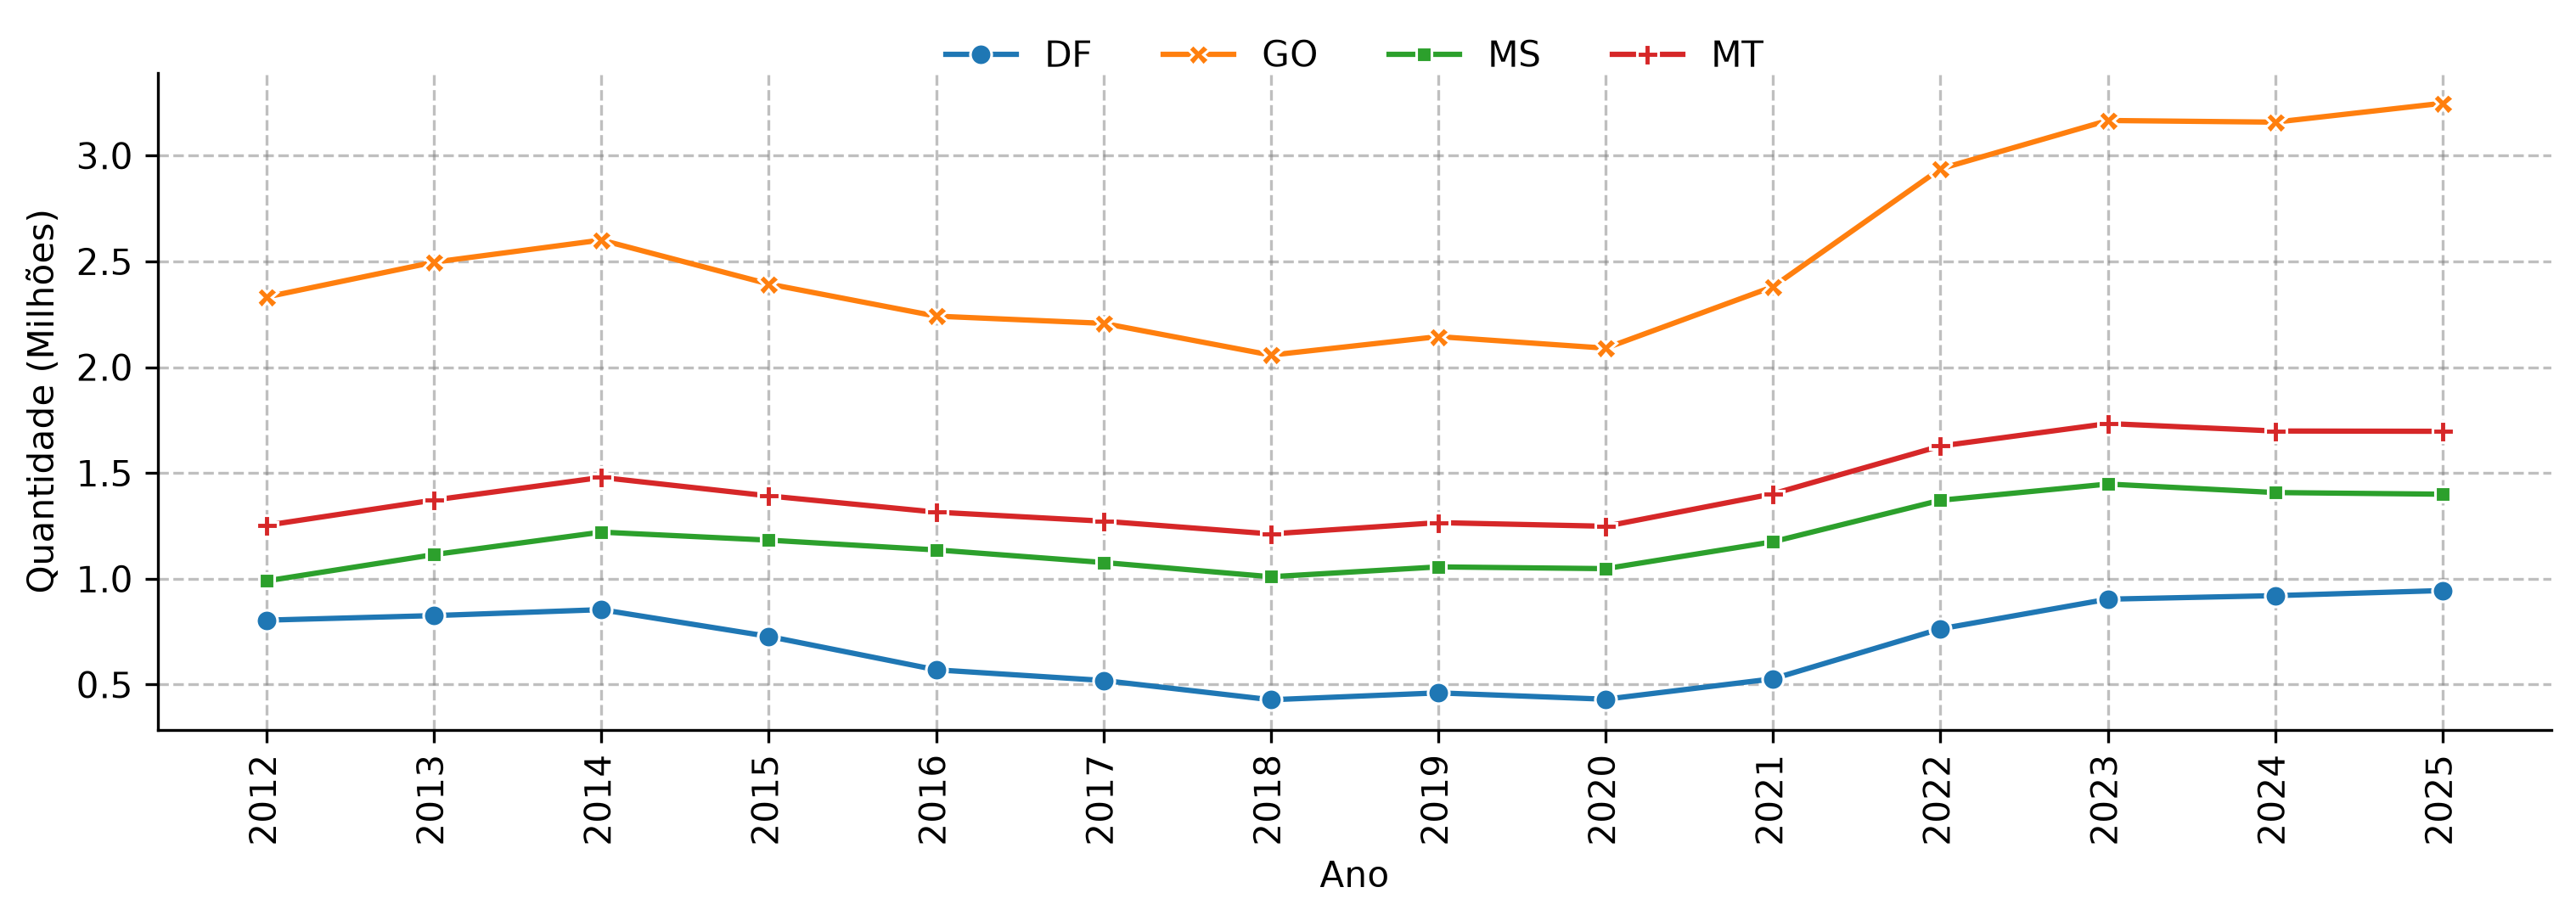

Nordeste


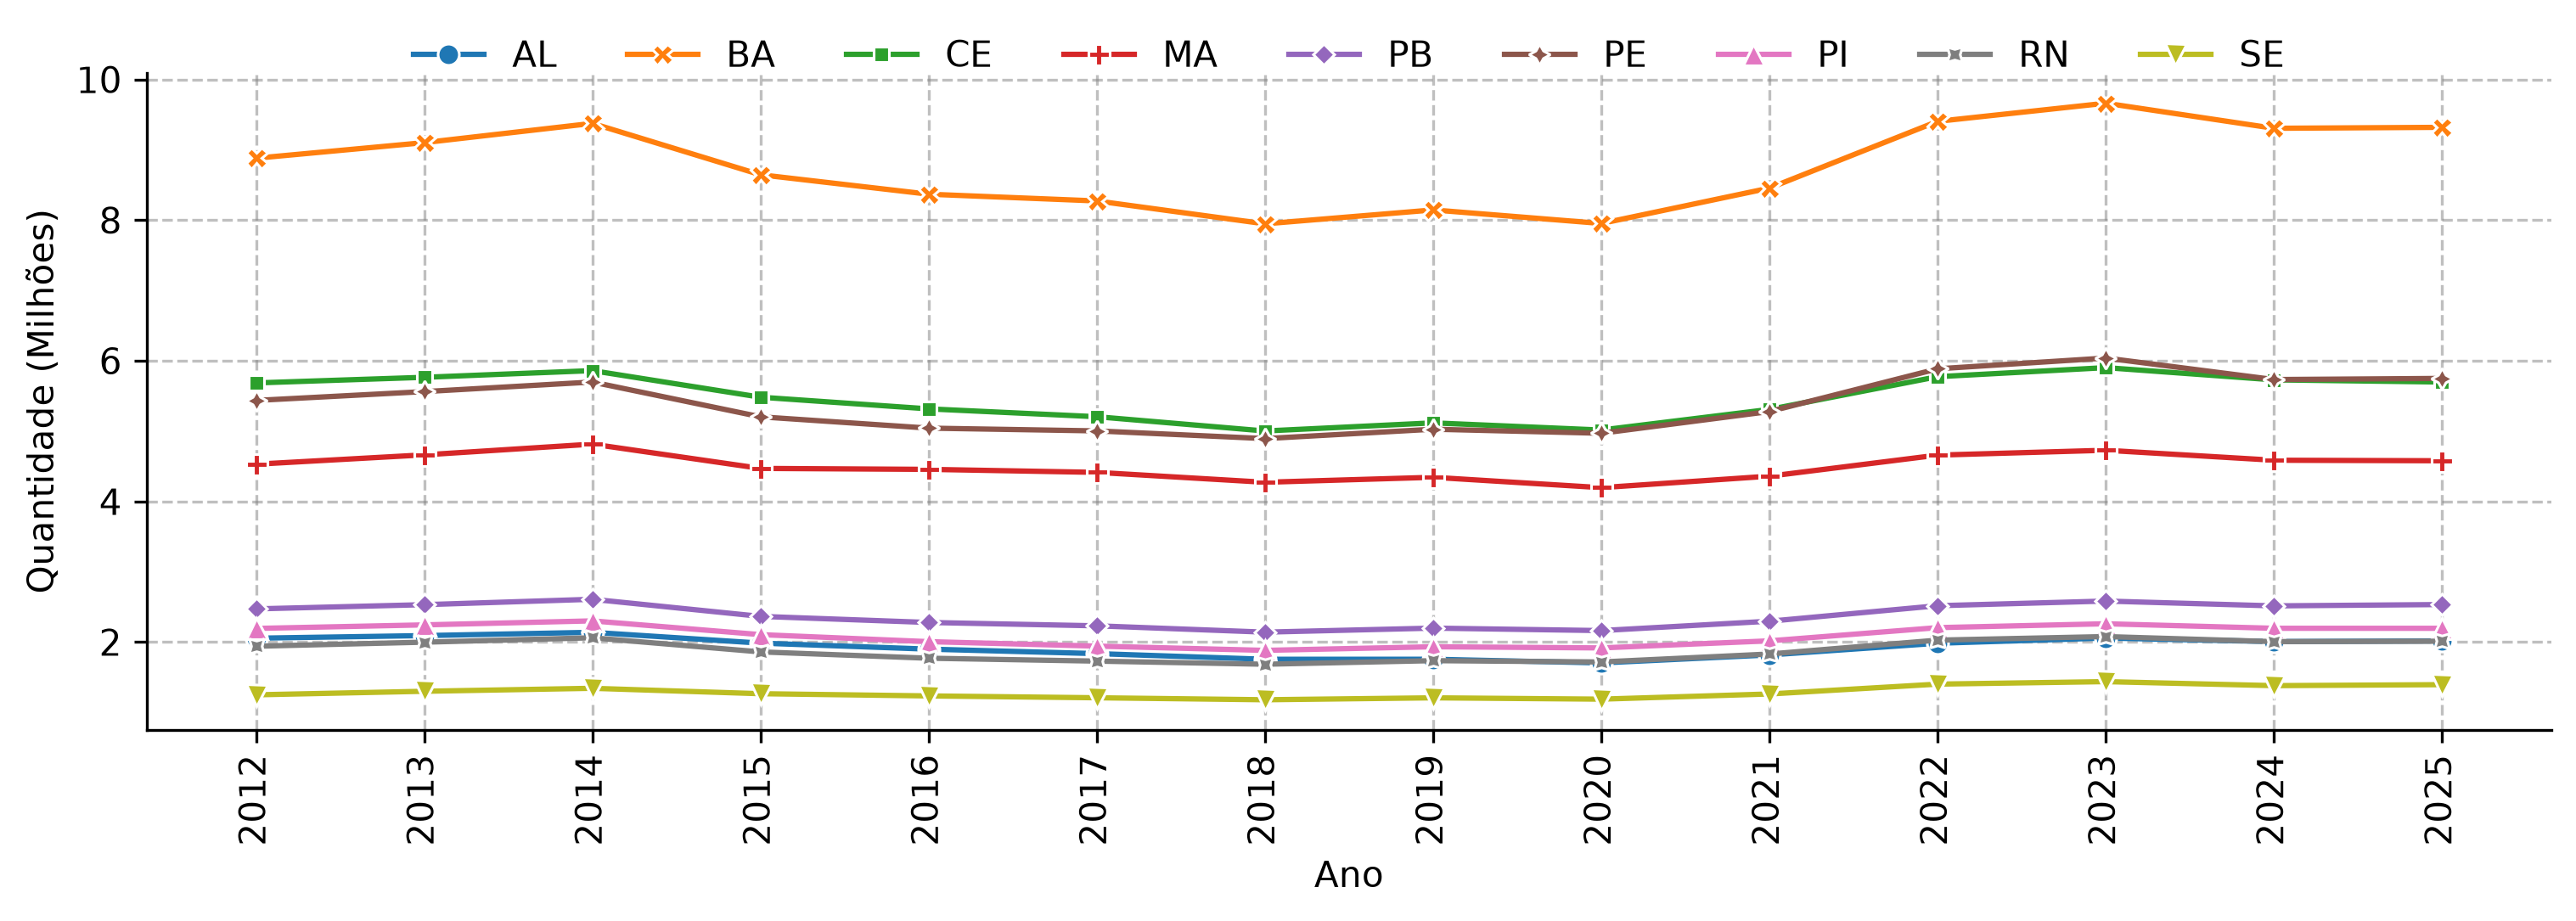

Norte


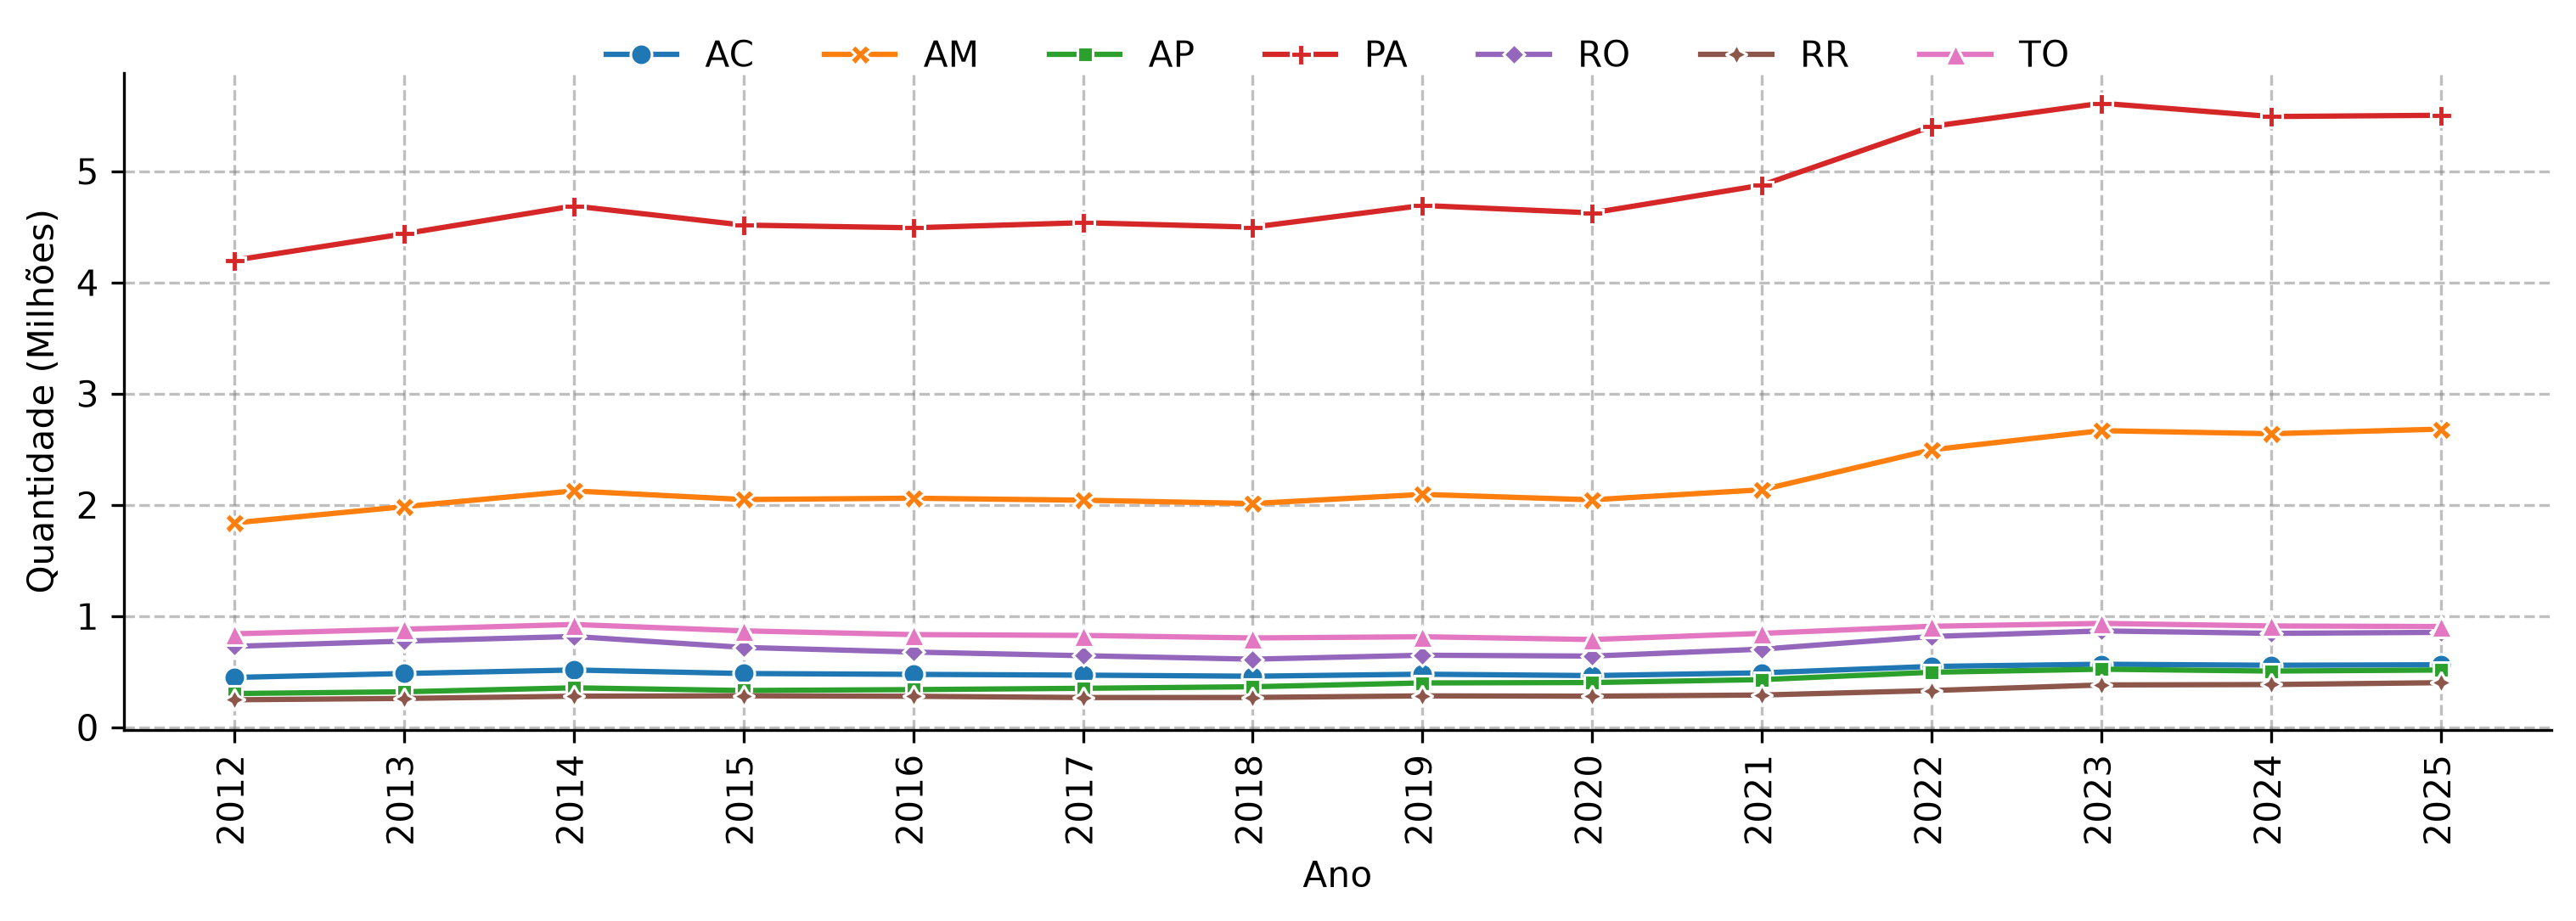

Sudeste


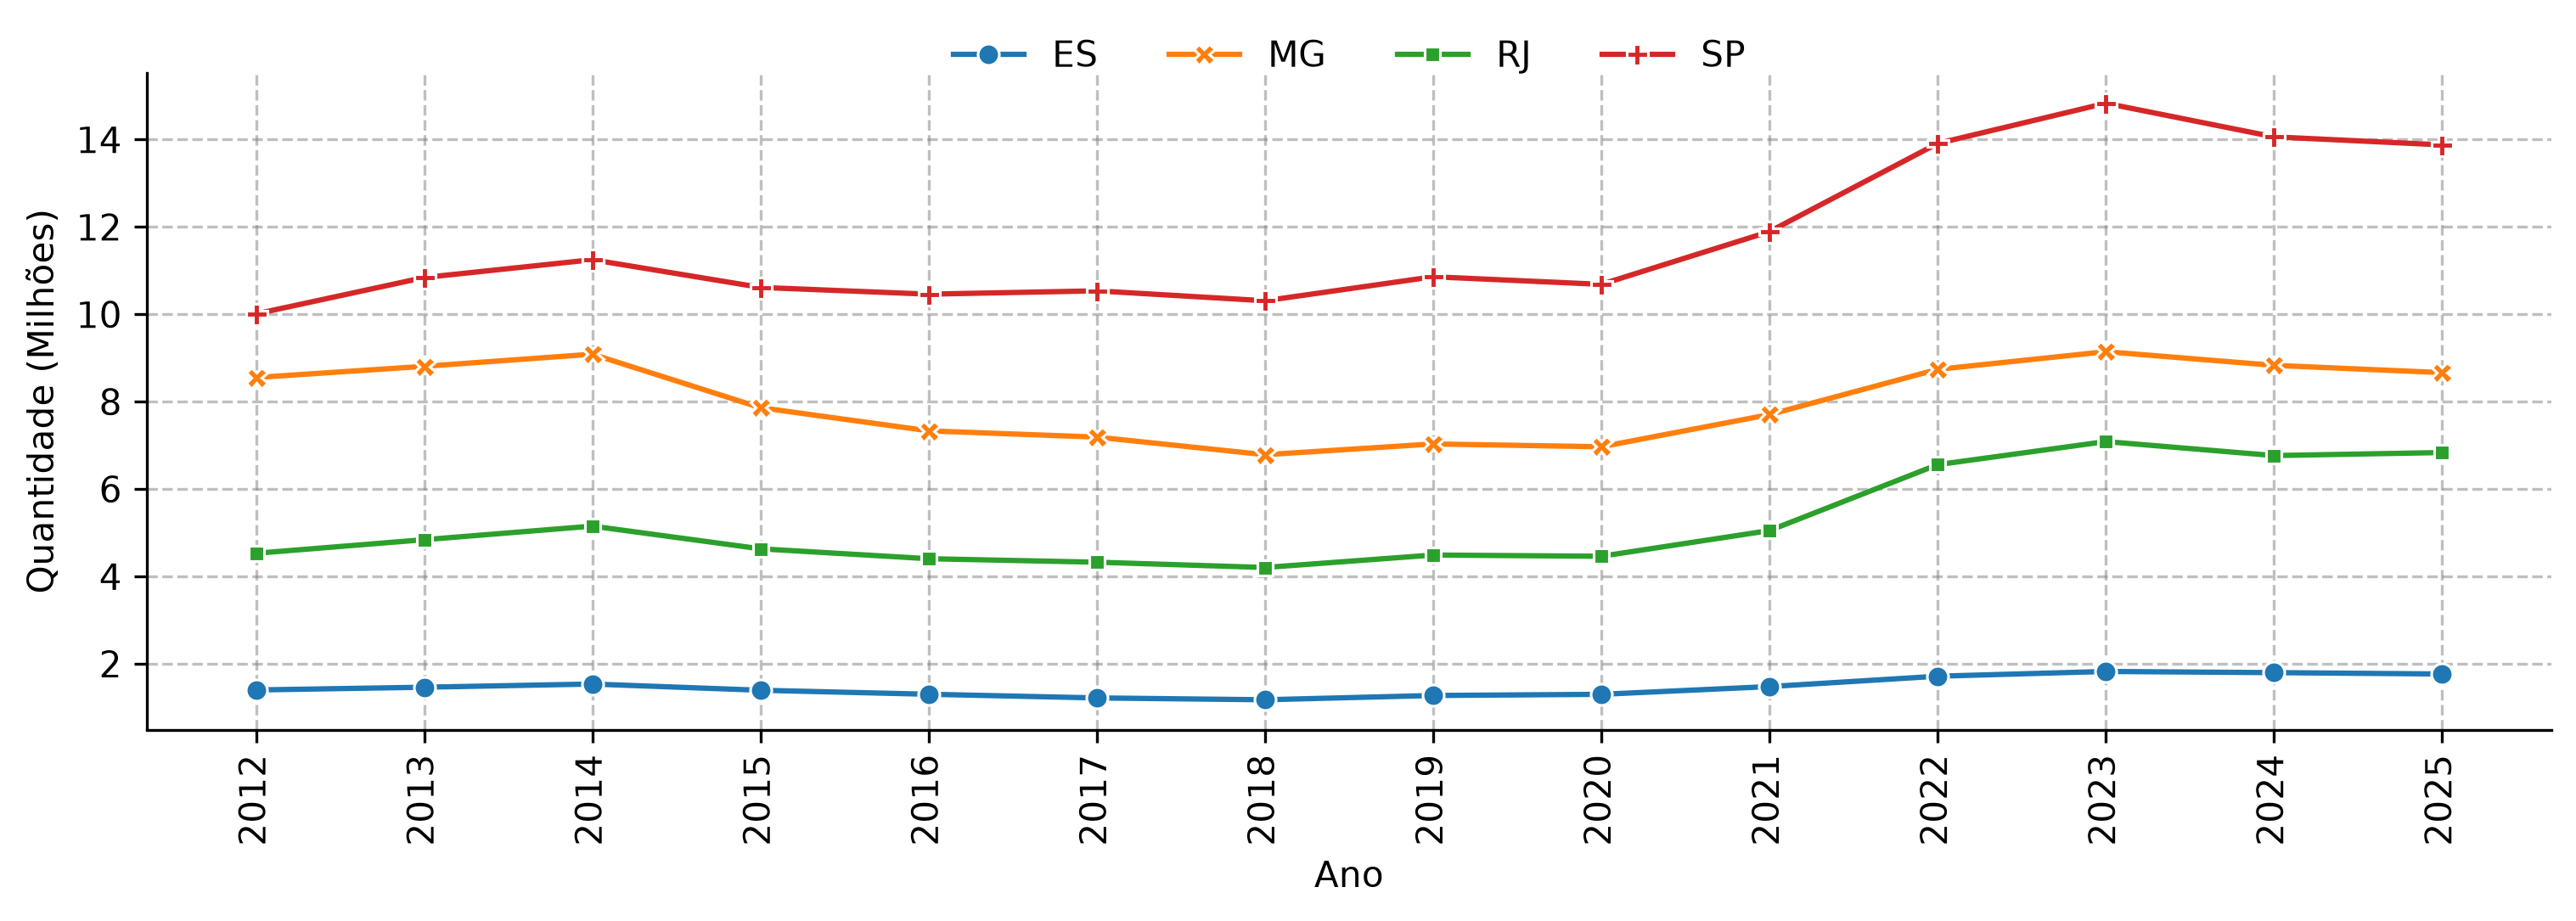

Sul


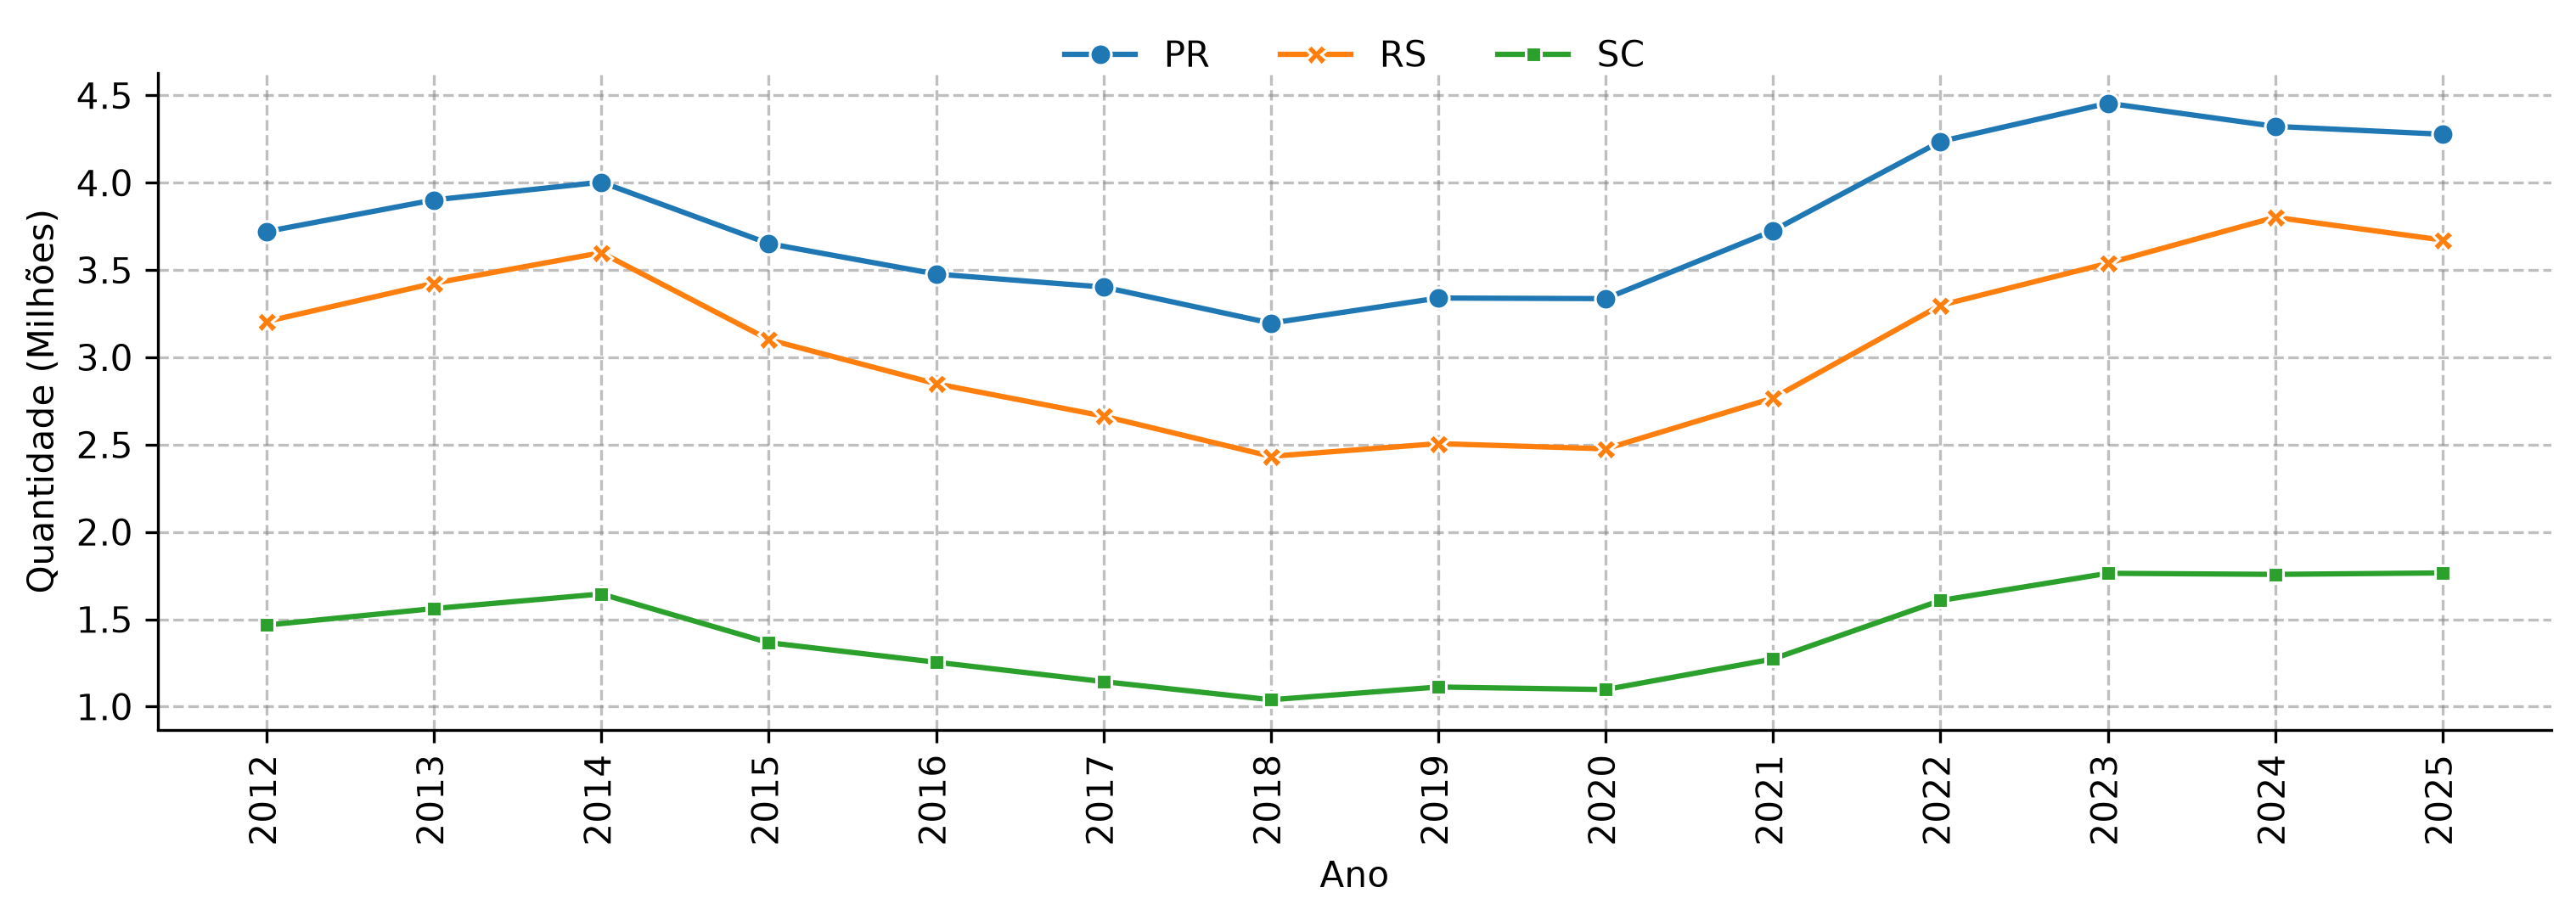

In [20]:
for (regiao, df_por_regiao) in df_qtde_pessoas_por_ano_regiao_uf.groupby('regiao'):
    print(regiao)

    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df_por_regiao,
        x='ano',
        y='qtde_1e6',
        hue='sigla_uf',
        style='sigla_uf',
        markers=True,
        errorbar=None,
        dashes=False,
        ax=ax
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Quantidade (Milhões)')
    ax.set_xlabel('Ano')
    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=9, frameon=False)

    fig.savefig(f'pessoas_cadunico_ufs_{regiao.lower()}', dpi=300, bbox_inches='tight')
    plt.show()

In [21]:
df_qtde_familias_por_ano_regiao_uf = df_qtde_por_ano_regiao_uf.query('grupo == "Famílias"')

In [22]:
df_qtde_familias_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,uf,qtde,qtde_1e6
27,2012,Famílias,Centro-oeste,DF,Distrito Federal,239813,0.239813
28,2012,Famílias,Centro-oeste,GO,Goiás,740489,0.740489
29,2012,Famílias,Centro-oeste,MS,Mato Grosso do Sul,318332,0.318332
30,2012,Famílias,Centro-oeste,MT,Mato Grosso,394821,0.394821
31,2012,Famílias,Nordeste,AL,Alagoas,639697,0.639697


Centro-oeste


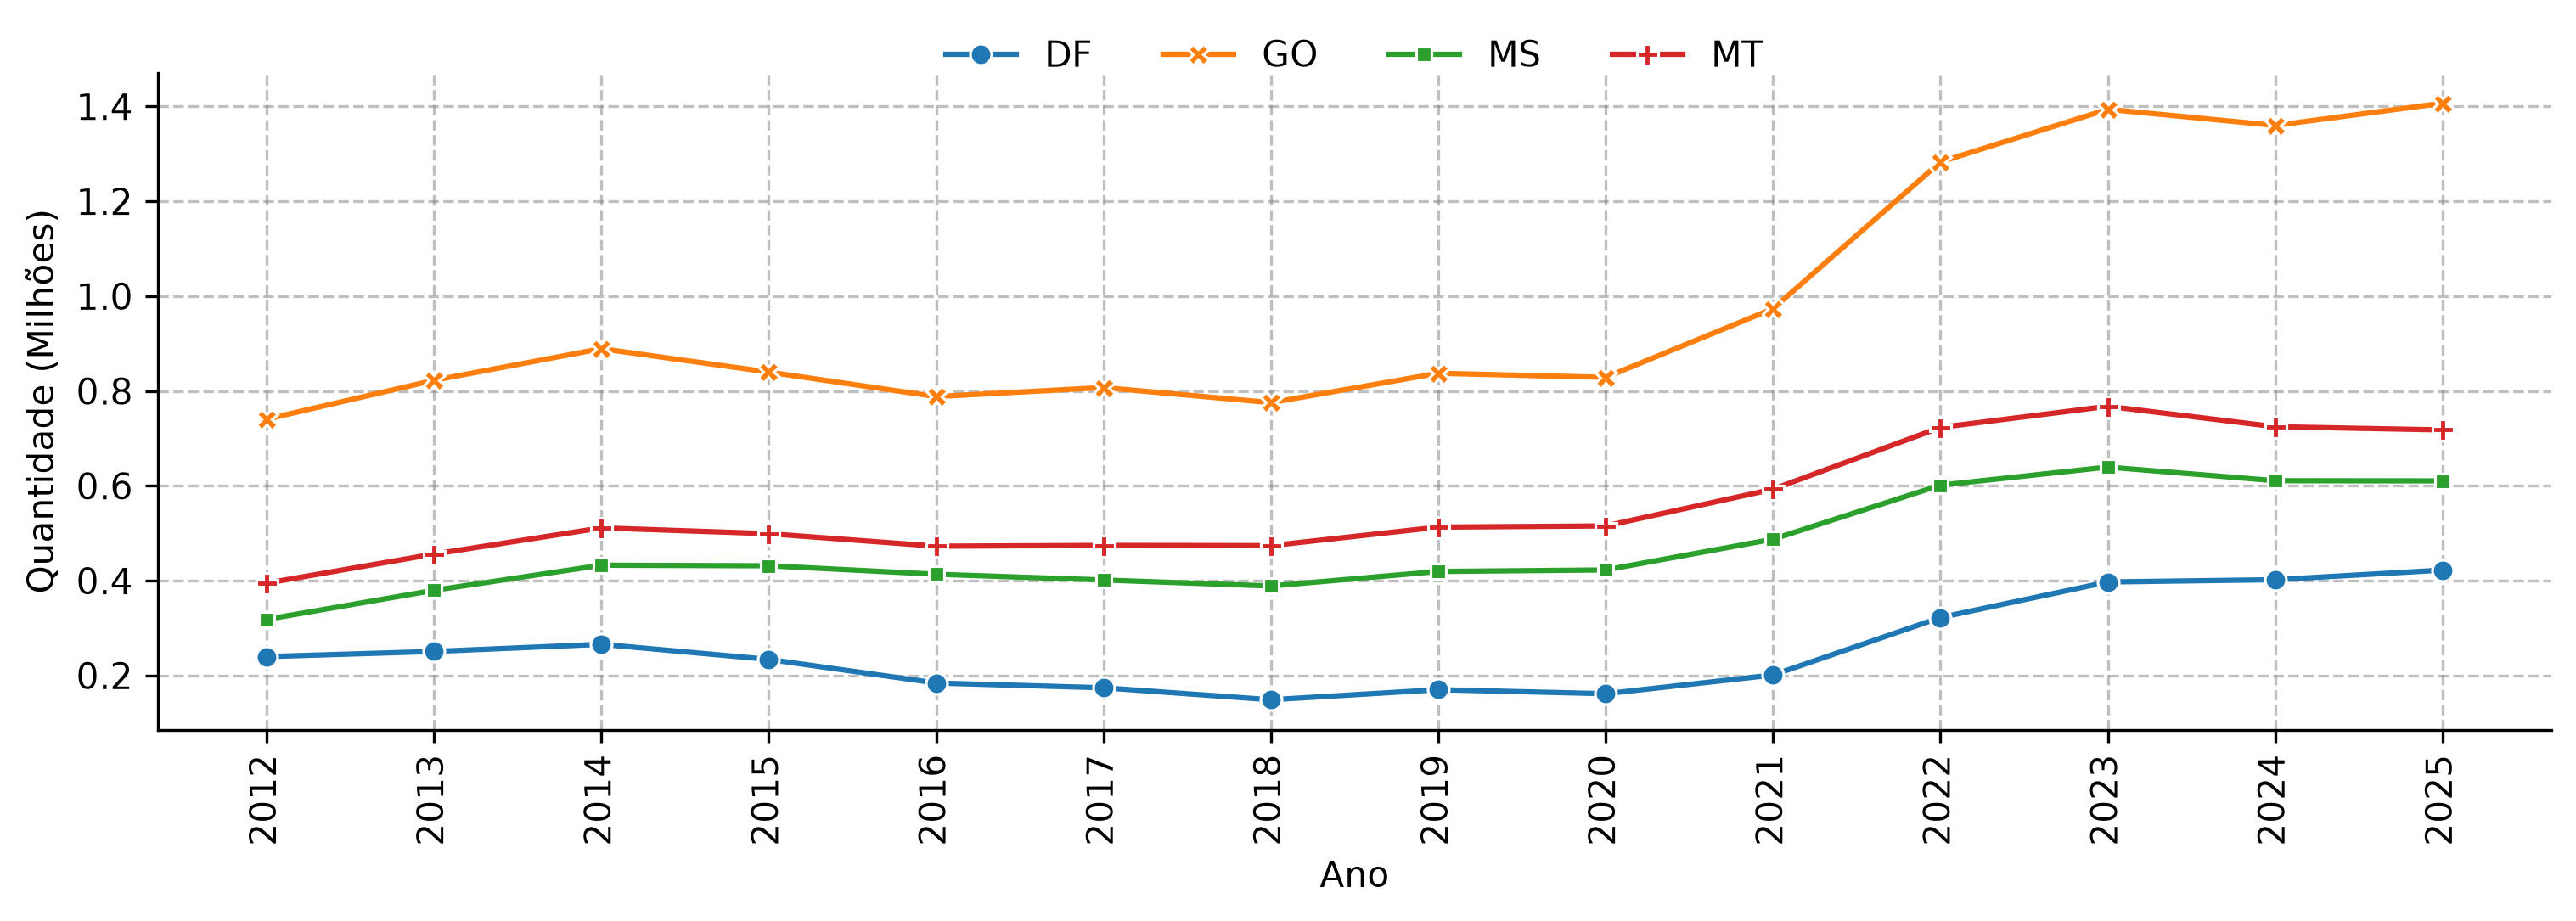

Nordeste


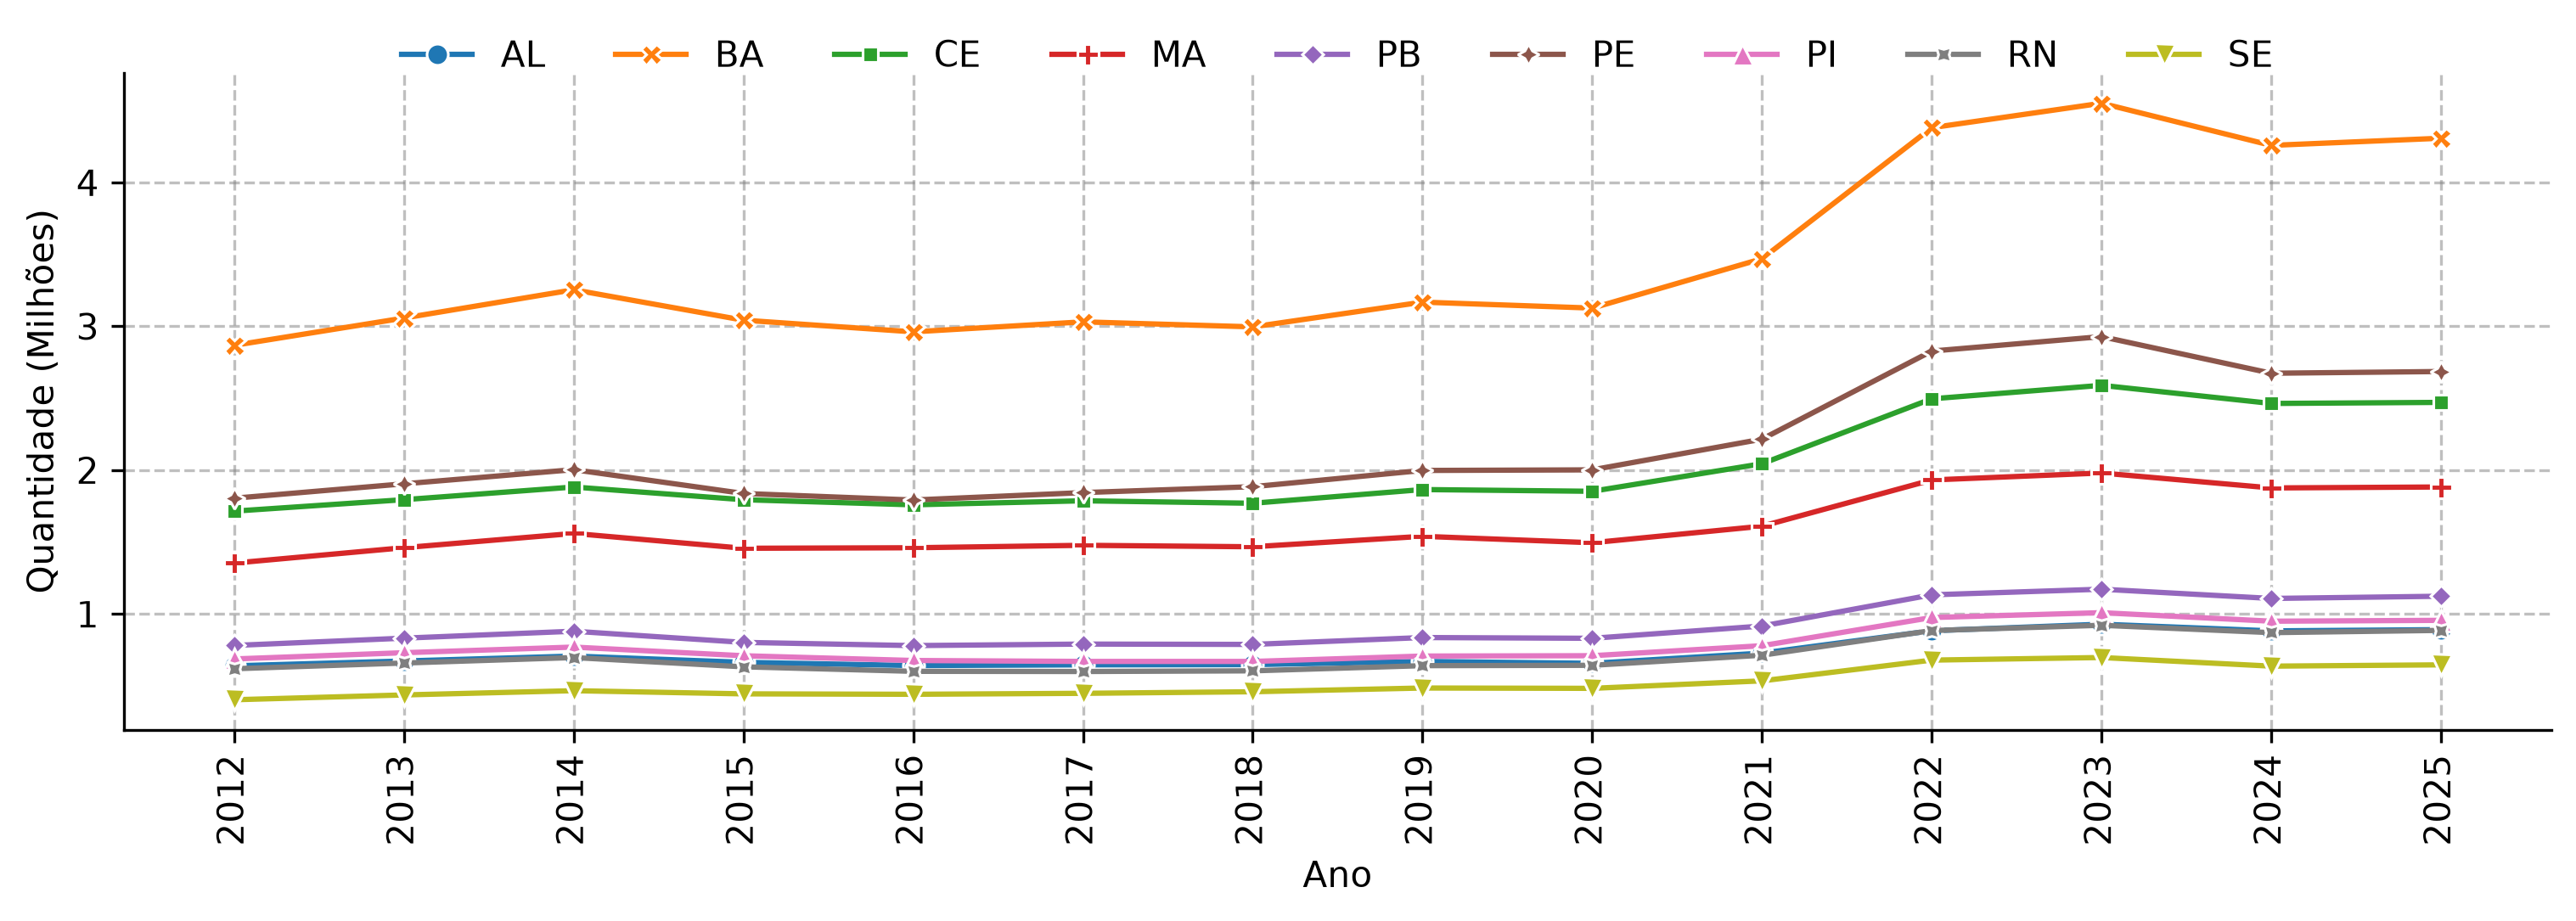

Norte


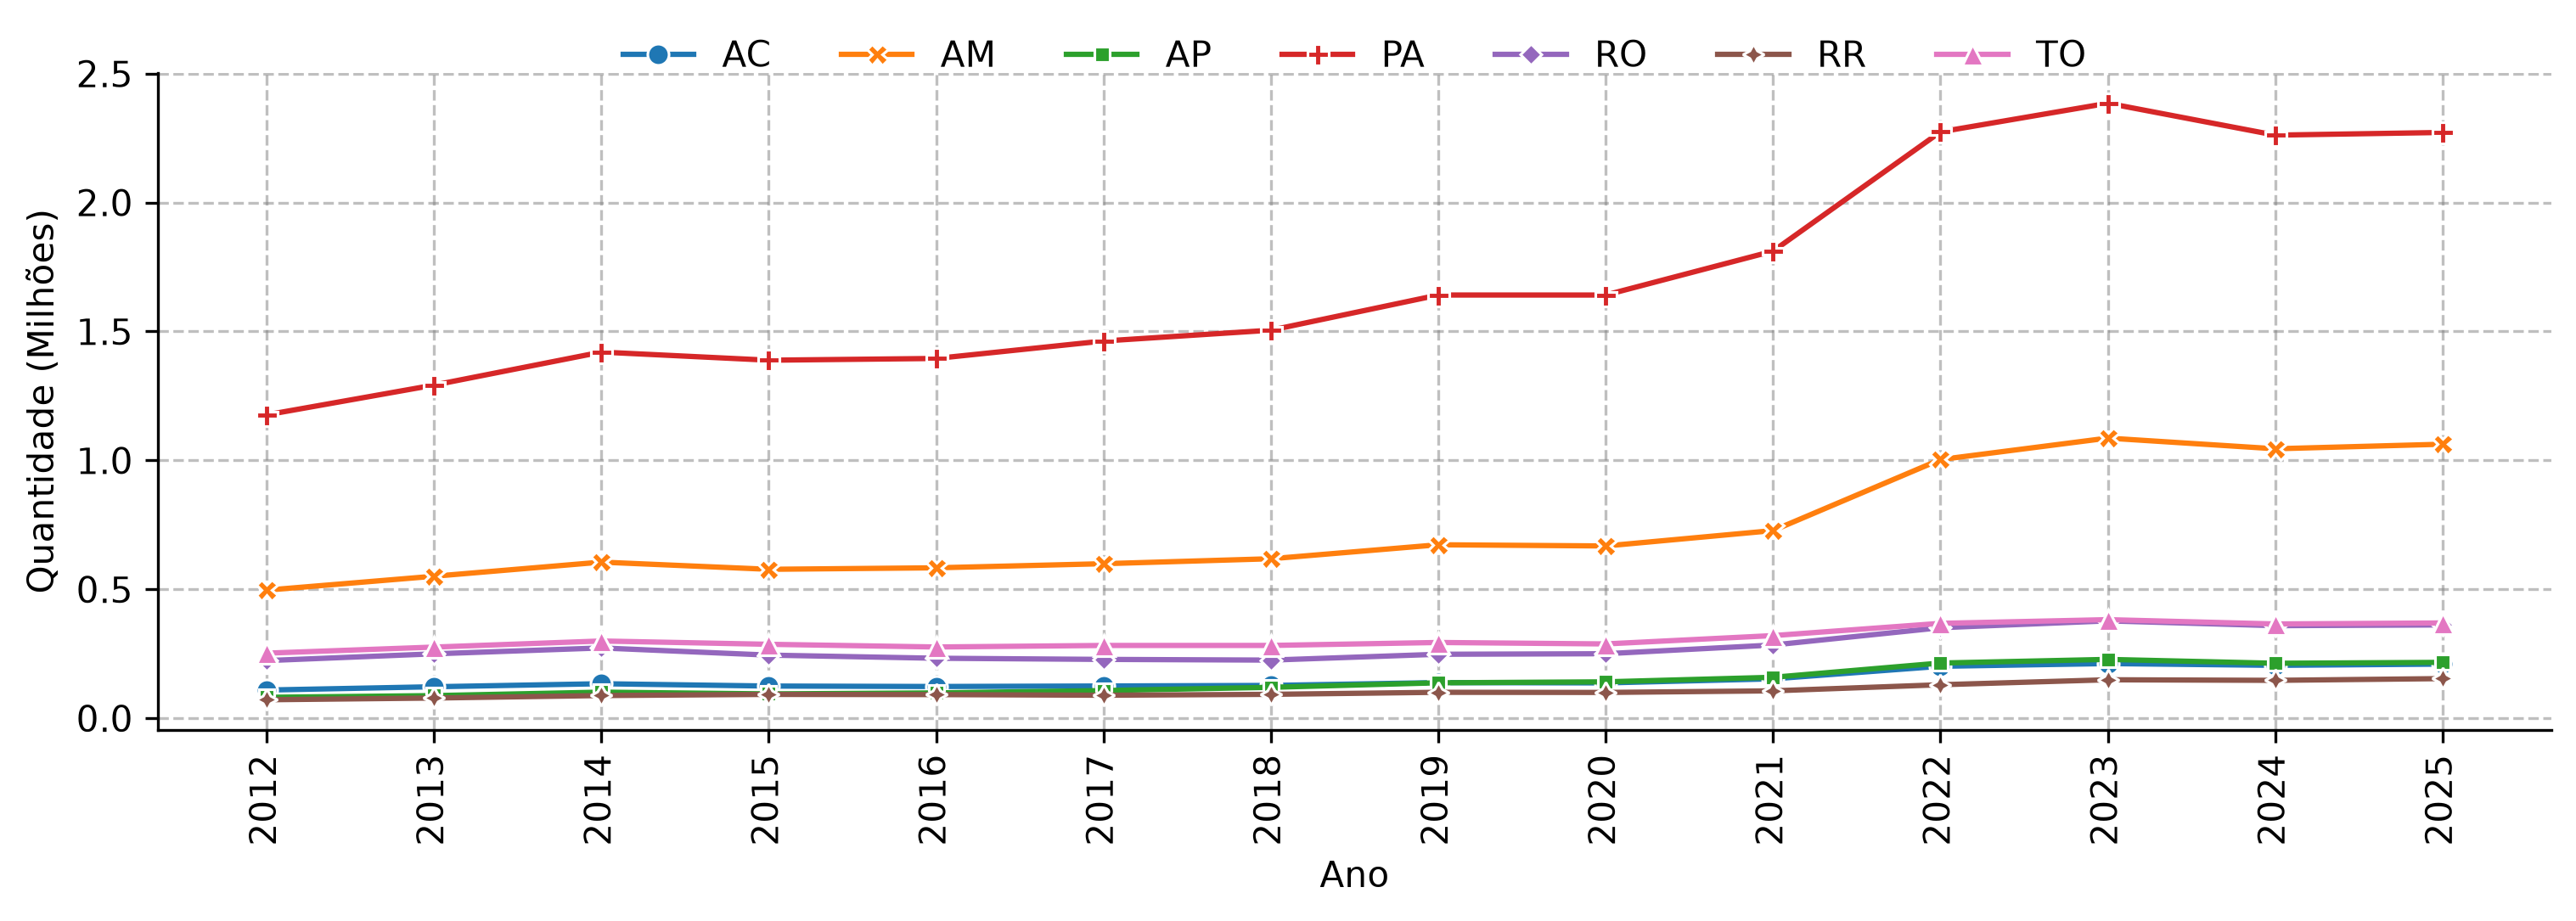

Sudeste


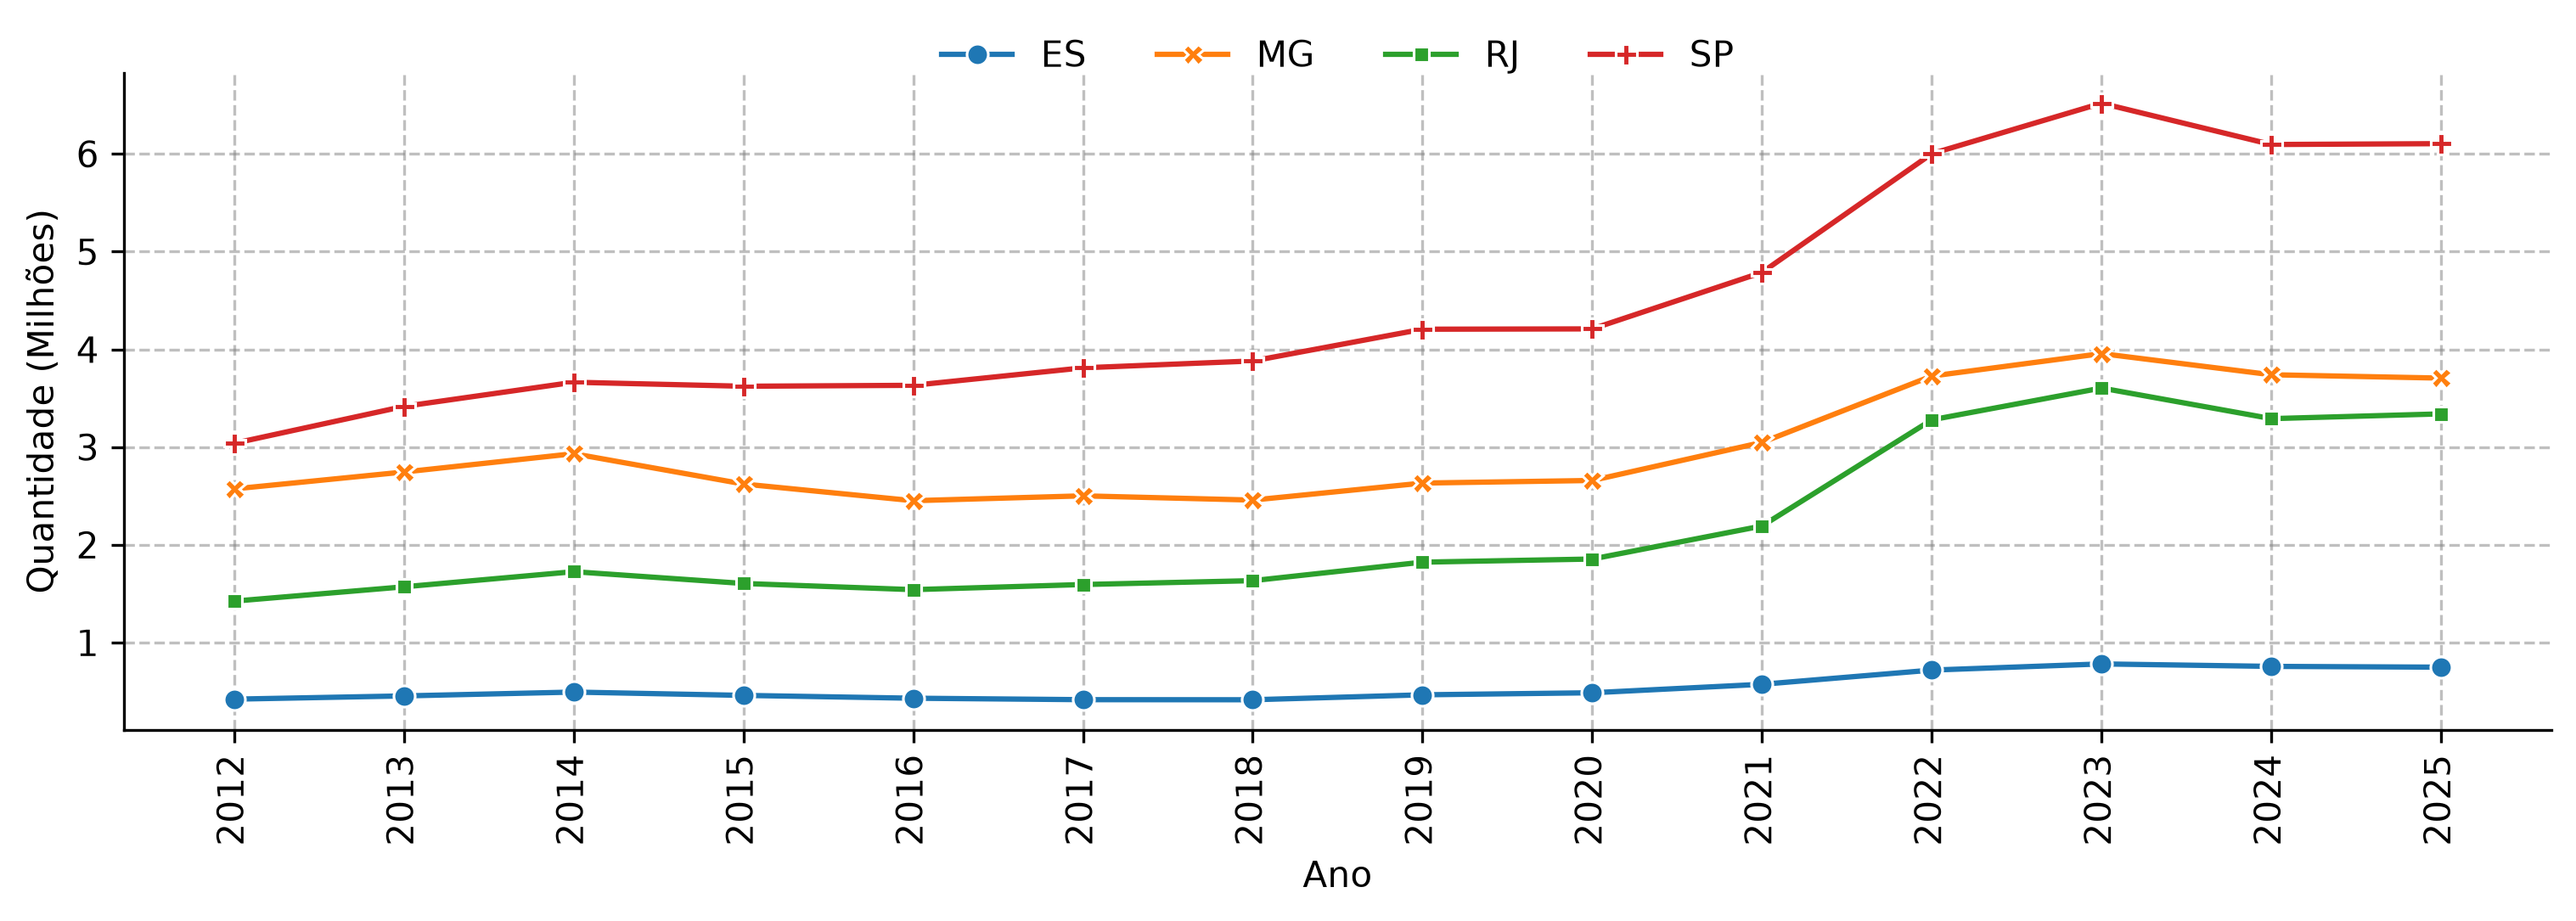

Sul


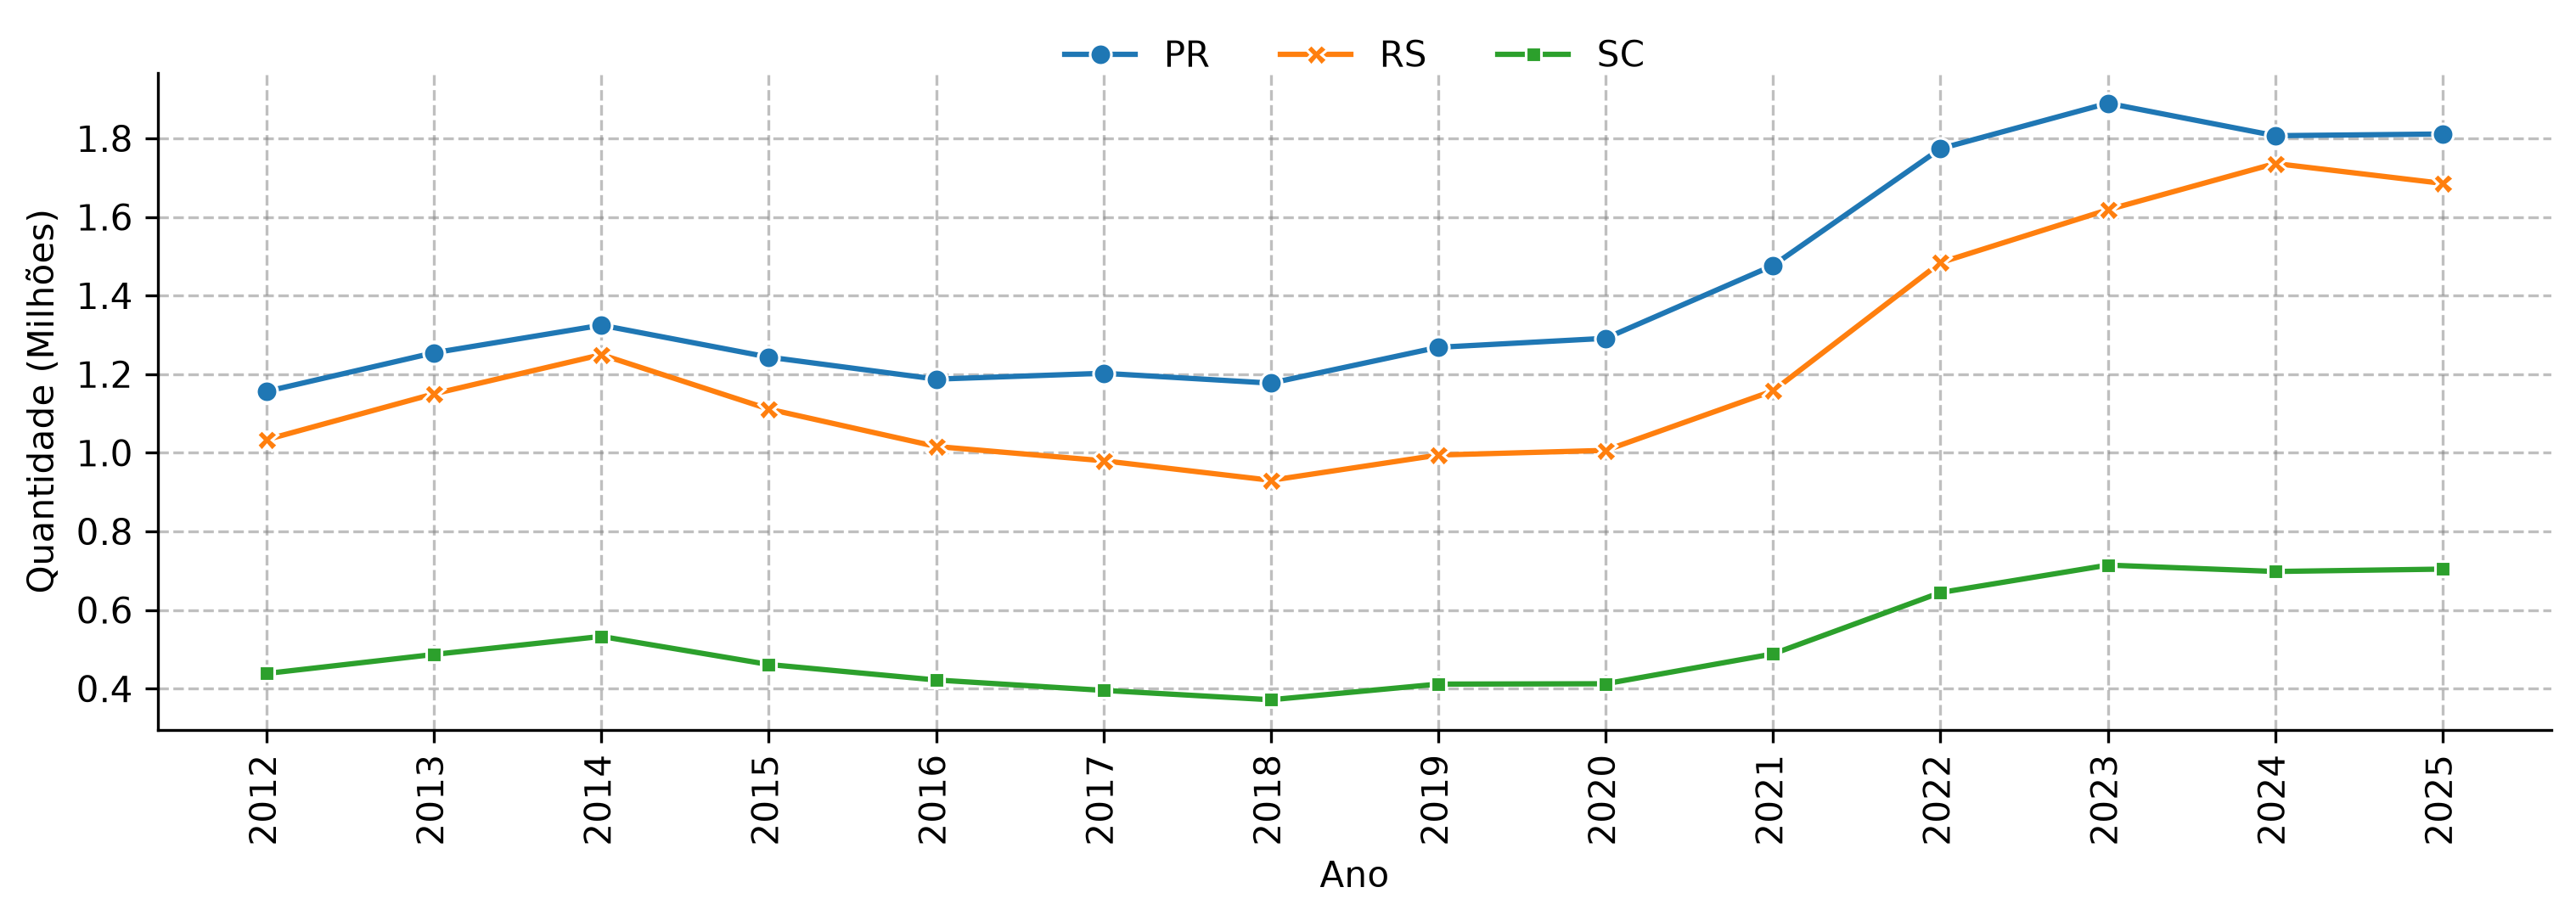

In [23]:
for (regiao, df_por_regiao) in df_qtde_familias_por_ano_regiao_uf.groupby('regiao'):
    print(regiao)

    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df_por_regiao,
        x='ano',
        y='qtde_1e6',
        hue='sigla_uf',
        style='sigla_uf',
        markers=True,
        errorbar=None,
        dashes=False,
        ax=ax
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Quantidade (Milhões)')
    ax.set_xlabel('Ano')
    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=9, frameon=False)

    fig.savefig(f'familias_cadunico_ufs_{regiao.lower()}', dpi=300, bbox_inches='tight')
    plt.show()

In [24]:
projecao_populacao = '../../compartilhado/projecoes_2024_tab1_idade_simples.ods'

In [25]:
pl.read_ods(projecao_populacao).write_parquet('../../compartilhado/projecao_populacao.parquet')

In [26]:
df_populacao = pd.read_parquet('../../compartilhado/projecao_populacao.parquet')

In [27]:
df_populacao.head()

,IDADE,SEXO,CÓD.,SIGLA,LOCAL,2000,2001,2002,2003,2004,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
0,0,Ambos,0,BR,Brasil,3423475,3347313,3274356,3212295,3163041,...,1615589,1597609,1580751,1564427,1549026,1534801,1521584,1509151,1497237,1485716
1,1,Ambos,0,BR,Brasil,3450022,3406966,3332612,3261091,3200484,...,1634395,1614666,1596716,1579885,1563579,1548205,1534002,1520805,1508394,1496496
2,2,Ambos,0,BR,Brasil,3461038,3444450,3401900,3327924,3256791,...,1655206,1633932,1614217,1596273,1579457,1563166,1547800,1533609,1520415,1508015
3,3,Ambos,0,BR,Brasil,3469109,3458052,3441638,3399284,3325501,...,1676639,1654738,1633474,1613776,1595841,1579039,1562761,1547399,1533216,1520035
4,4,Ambos,0,BR,Brasil,3477903,3466901,3455987,3439662,3397467,...,1697627,1676166,1654275,1633030,1613338,1595416,1578625,1562356,1547006,1532831


In [28]:
df_populacao.dtypes

IDADE    int64
SEXO       str
CÓD.     int64
SIGLA      str
LOCAL      str
         ...  
2066     int64
2067     int64
2068     int64
2069     int64
2070     int64
Length: 76, dtype: object

In [29]:
df_populacao.isna().sum()

IDADE    0
SEXO     0
CÓD.     0
SIGLA    0
LOCAL    0
        ..
2066     0
2067     0
2068     0
2069     0
2070     0
Length: 76, dtype: int64

In [30]:
df_populacao_brasil = (
    df_populacao.query('LOCAL == "Brasil" and SEXO == "Ambos"')
    .drop(columns=['IDADE', 'SEXO', 'CÓD.', 'SIGLA'])
    .melt(
        id_vars='LOCAL',
        value_vars=[str(ano) for ano in range(2012, 2026)],
        var_name='ano',
        value_name='populacao'
    )
    .drop(columns='LOCAL')
    .assign(ano=lambda x: pd.to_numeric(x['ano'], downcast='integer'))
    .groupby('ano')
    .agg('sum')
    .sort_values(by='ano')
    .reset_index()
    .assign(populacao_1e6 = lambda x: x['populacao'] / 1e6)
)


In [31]:
df_populacao_brasil.head()

,ano,populacao,populacao_1e6
0,2012,197670620,197.670620
1,2013,199226702,199.226702
2,2014,200811131,200.811131
3,2015,202403642,202.403642
4,2016,203871925,203.871925


In [32]:
df_populacao_brasil.dtypes

ano                int16
populacao          int64
populacao_1e6    float64
dtype: object

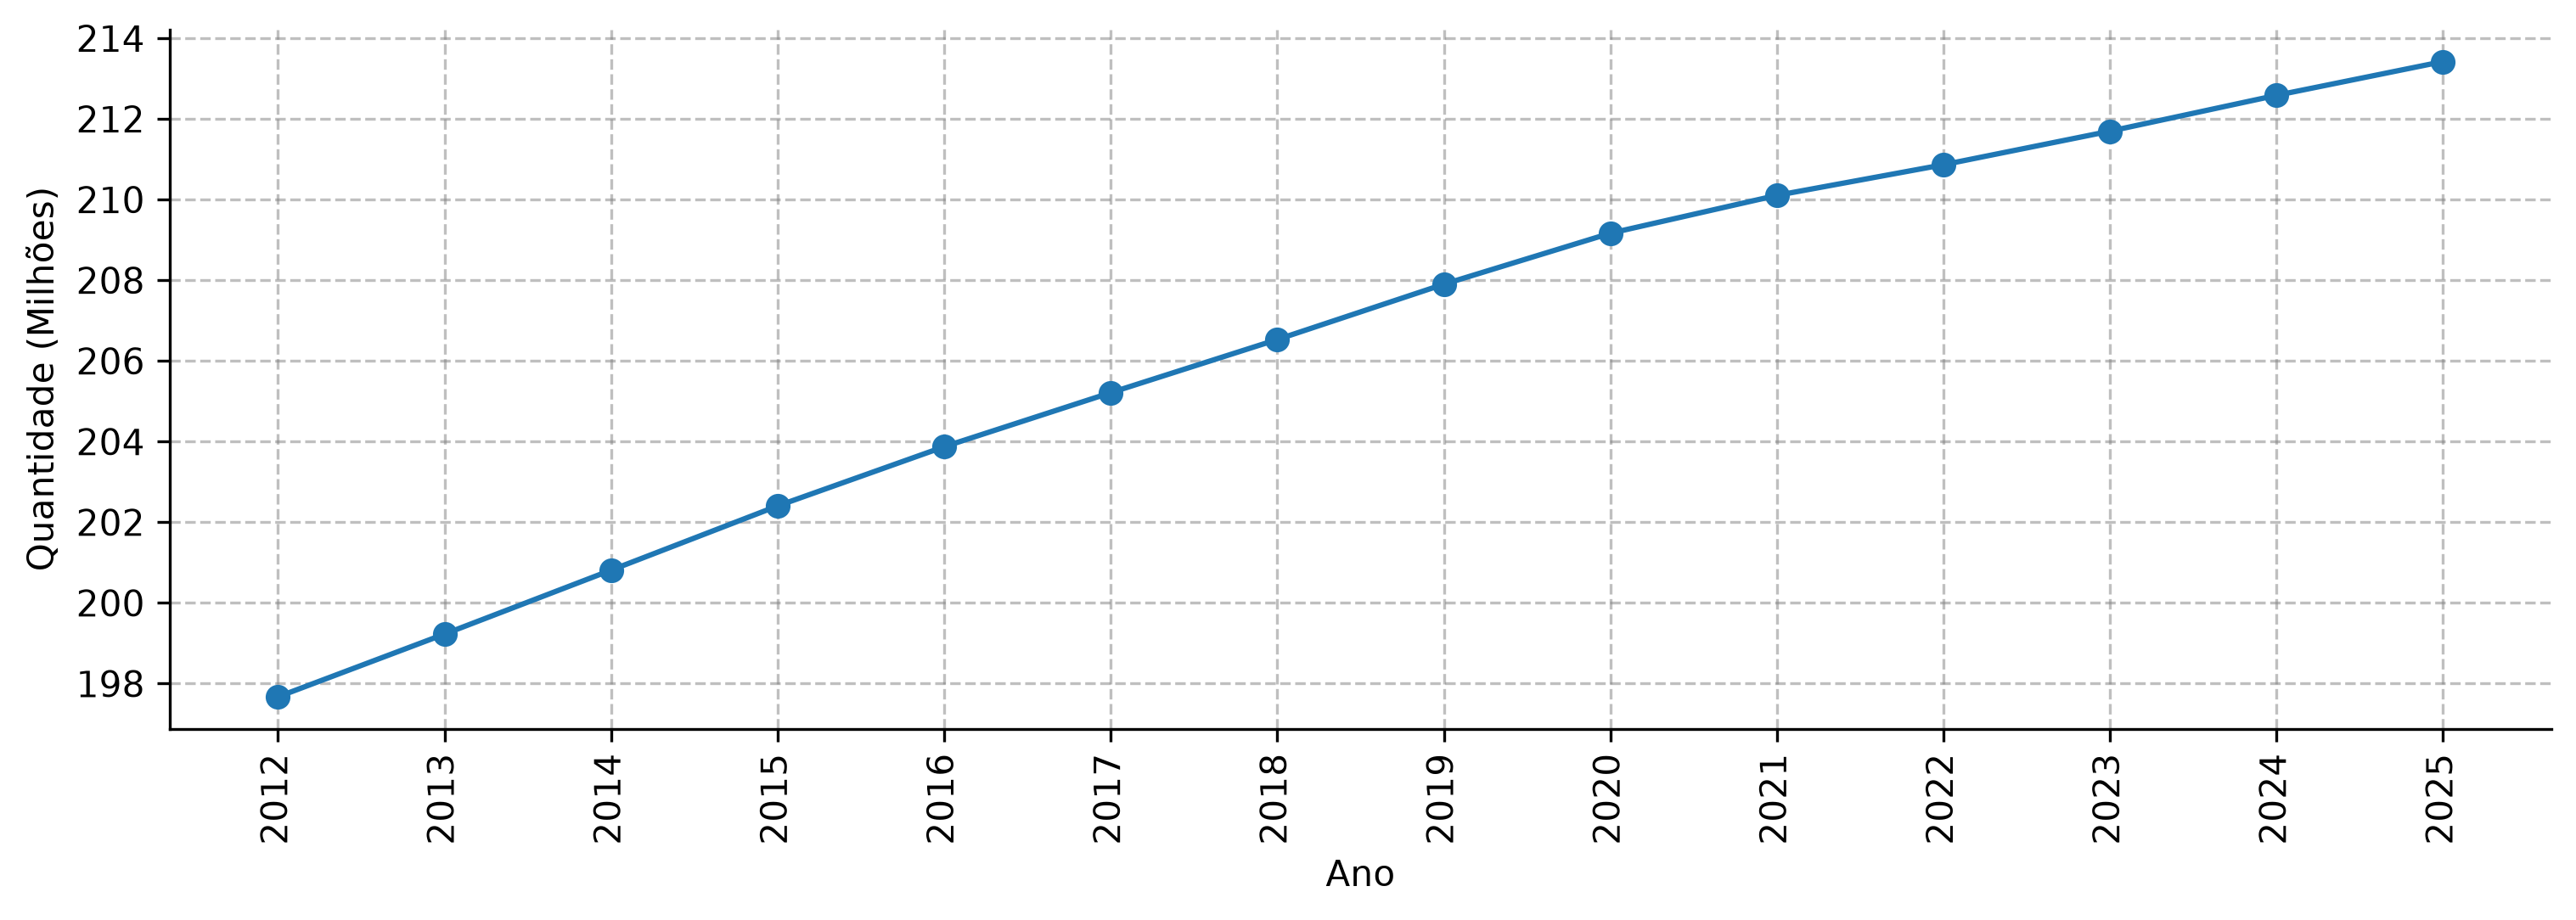

In [33]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

ax.plot(
    df_populacao_brasil['ano'],
    df_populacao_brasil['populacao_1e6'],
    marker='o'
)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Quantidade (Milhões)')
ax.set_xlabel('Ano')
ax.set_xticks(anos, labels=anos, rotation=90)
ax.grid(color='grey', linestyle='--', alpha=0.5)

fig.savefig('projecao_populacao_brasil_2012_2025', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
df_qtde_por_ano.head()

,ano,grupo,qtde,qtde_1e6
0,2012,Pessoas,81322507,81.322507
1,2012,Famílias,25063802,25.063802
2,2013,Pessoas,85057820,85.057820
3,2013,Famílias,27194588,27.194588
4,2014,Pessoas,88339340,88.339340


In [35]:
df_populacao_brasil.head()

,ano,populacao,populacao_1e6
0,2012,197670620,197.670620
1,2013,199226702,199.226702
2,2014,200811131,200.811131
3,2015,202403642,202.403642
4,2016,203871925,203.871925


In [36]:
pct_qtde_pessoas_no_cadunico_na_populacao_por_ano = (
    df_qtde_por_ano.query('grupo == "Pessoas"')
    .drop(columns='grupo')
    .reset_index(drop=True)
    .assign(pct = lambda x: ((x['qtde'] / df_populacao_brasil['populacao']) * 100).round(2))
)

In [37]:
pct_qtde_pessoas_no_cadunico_na_populacao_por_ano.head()

,ano,qtde,qtde_1e6,pct
0,2012,81322507,81.322507,41.14
1,2013,85057820,85.057820,42.69
2,2014,88339340,88.339340,43.99
3,2015,80954053,80.954053,40.00
4,2016,77878526,77.878526,38.20


In [38]:
pct_qtde_pessoas_no_cadunico_na_populacao_por_ano.isna().sum()

ano         0
qtde        0
qtde_1e6    0
pct         0
dtype: int64

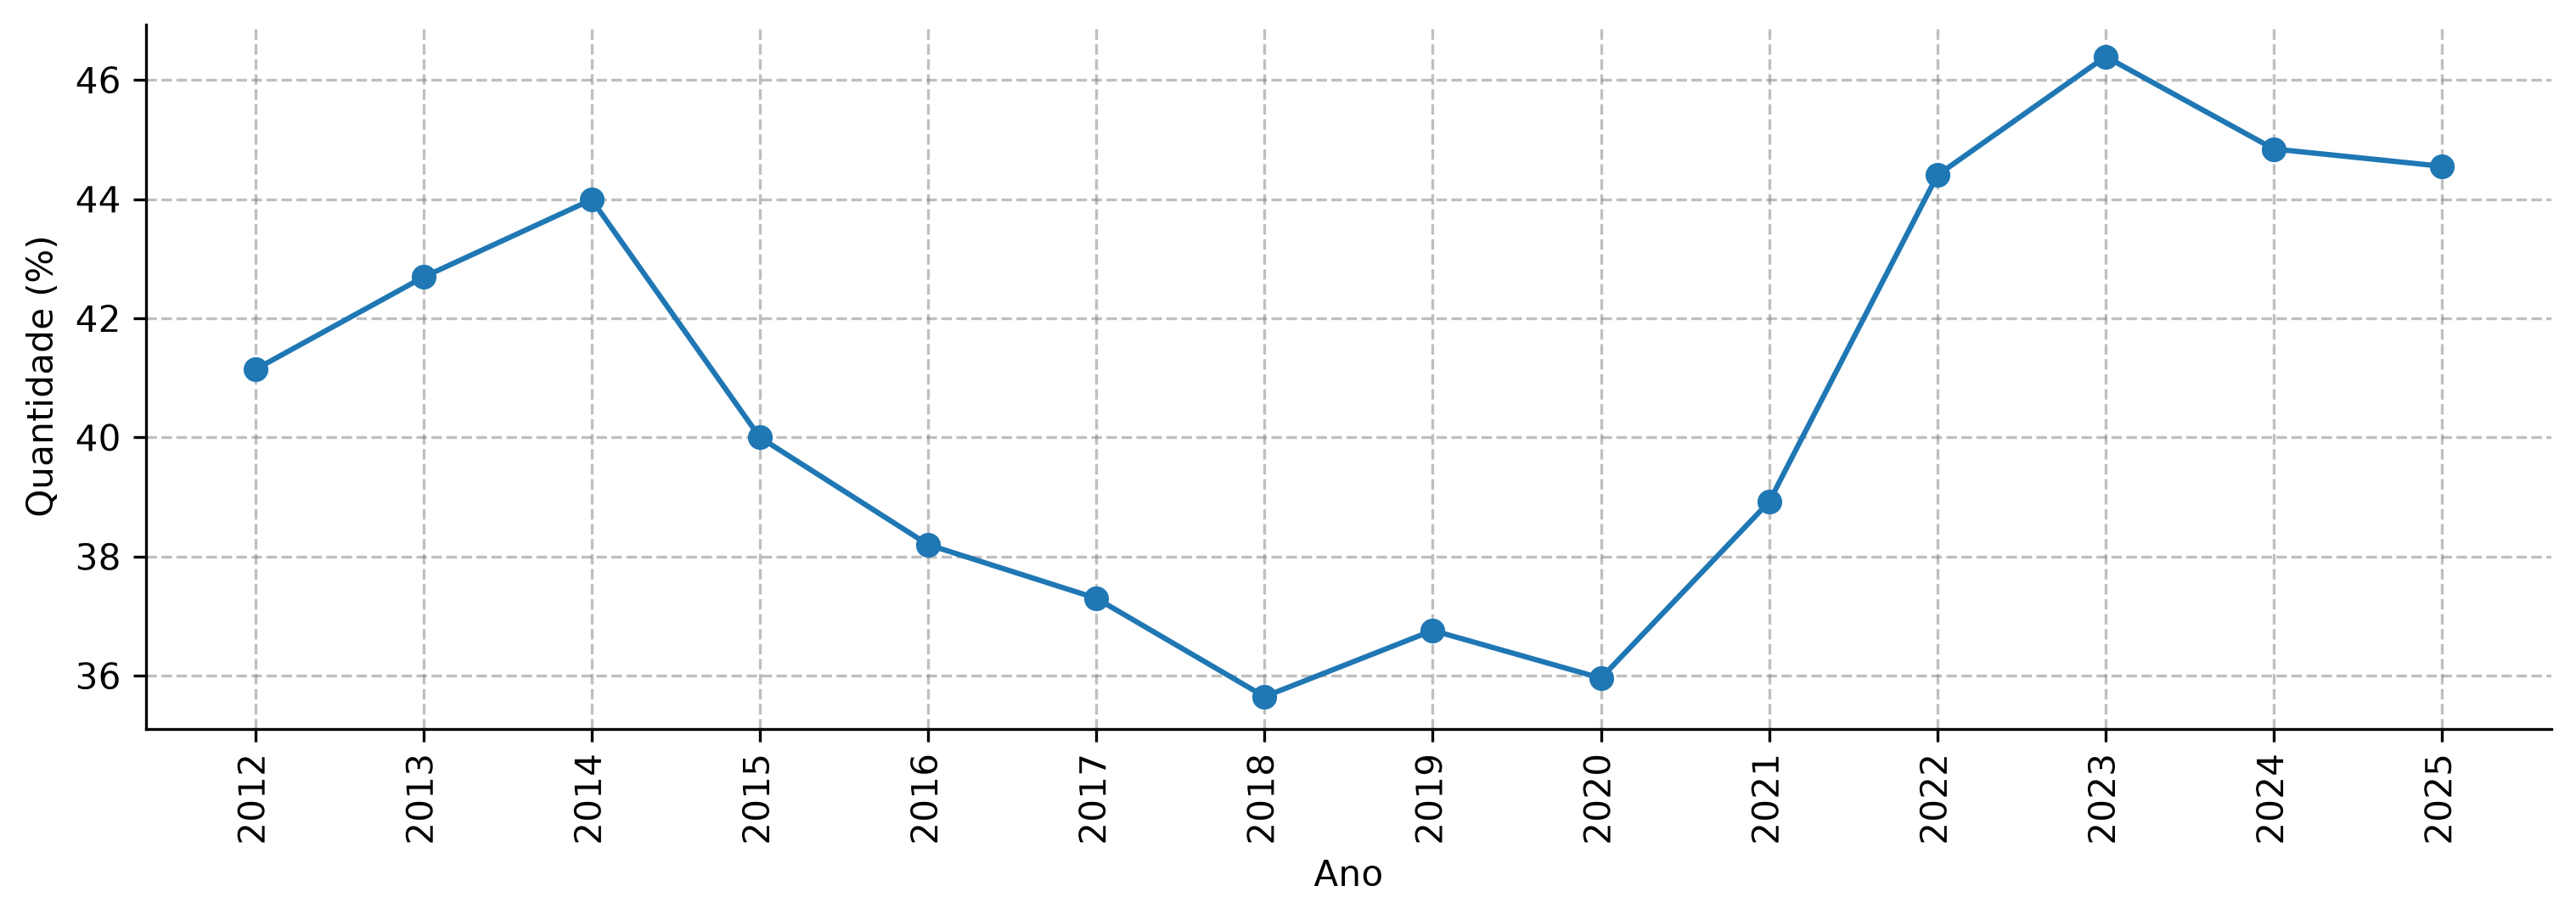

In [39]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

ax.plot(
    pct_qtde_pessoas_no_cadunico_na_populacao_por_ano['ano'],
    pct_qtde_pessoas_no_cadunico_na_populacao_por_ano['pct'],
    marker='o'
)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Quantidade (%)')
ax.set_xlabel('Ano')
ax.set_xticks(anos, labels=anos, rotation=90)
ax.grid(color='grey', linestyle='--', alpha=0.5)

fig.savefig('pct_qtde_pessoas_no_cadunico_na_populacao_por_ano', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
df_populacao['LOCAL'].unique()

<ArrowStringArray>
[             'Brasil',               'Norte',            'Nordeste',
             'Sudeste',                 'Sul',        'Centro-Oeste',
            'Rondônia',                'Acre',            'Amazonas',
             'Roraima',                'Pará',               'Amapá',
           'Tocantins',            'Maranhão',               'Piauí',
               'Ceará', 'Rio Grande do Norte',             'Paraíba',
          'Pernambuco',             'Alagoas',             'Sergipe',
               'Bahia',        'Minas Gerais',      'Espírito Santo',
      'Rio de Janeiro',           'São Paulo',              'Paraná',
      'Santa Catarina',   'Rio Grande do Sul',  'Mato Grosso do Sul',
         'Mato Grosso',               'Goiás',    'Distrito Federal']
Length: 33, dtype: str

In [41]:
regioes = ['Norte', 'Nordeste', 'Sul', 'Sudeste', 'Centro-Oeste']

In [42]:
df_populacao_regioes = (
    df_populacao.query('LOCAL in @regioes and SEXO == "Ambos"')
    .drop(columns=['IDADE', 'SEXO', 'CÓD.', 'SIGLA'])
    .rename(columns={
        'LOCAL': 'regiao'
    })
    .replace({
        'Centro-Oeste': 'Centro-oeste'
    })
    .melt(
        id_vars='regiao',
        value_vars=[str(ano) for ano in range(2012, 2026)],
        var_name='ano',
        value_name='populacao'
    )
    .assign(ano = lambda x: pd.to_numeric(x['ano'], downcast='integer'))
    .groupby(['regiao', 'ano'])
    .agg('sum')
    .reset_index()
)

In [43]:
df_populacao_regioes.head()

,regiao,ano,populacao
0,Centro-oeste,2012,14783413
1,Centro-oeste,2013,14984338
2,Centro-oeste,2014,15193306
3,Centro-oeste,2015,15405701
4,Centro-oeste,2016,15608920


In [44]:
df_populacao_regioes['regiao'].unique()

<ArrowStringArray>
['Centro-oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
Length: 5, dtype: str

In [45]:
df_populacao_regioes.dtypes

regiao         str
ano          int16
populacao    int64
dtype: object

In [46]:
df_qtde_por_ano_regiao.head()

,ano,grupo,regiao,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,5378848,5.378848
1,2012,Pessoas,Nordeste,34445665,34.445665
2,2012,Pessoas,Norte,8612913,8.612913
3,2012,Pessoas,Sudeste,24492487,24.492487
4,2012,Pessoas,Sul,8392594,8.392594


In [47]:
df_qtde_por_ano_regiao['grupo'].unique()

['Pessoas', 'Famílias']
Categories (2, str): ['Pessoas', 'Famílias']

In [48]:
df_qtde_pessoas_por_ano_regiao = df_qtde_por_ano_regiao.query('grupo == "Pessoas"')

In [49]:
df_qtde_pessoas_por_ano_regiao.head()

,ano,grupo,regiao,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,5378848,5.378848
1,2012,Pessoas,Nordeste,34445665,34.445665
2,2012,Pessoas,Norte,8612913,8.612913
3,2012,Pessoas,Sudeste,24492487,24.492487
4,2012,Pessoas,Sul,8392594,8.392594


In [50]:
df_qtde_pessoas_por_ano_regiao['grupo'].unique()

['Pessoas']
Categories (2, str): ['Pessoas', 'Famílias']

In [51]:
df_populacao_regioes.head()

,regiao,ano,populacao
0,Centro-oeste,2012,14783413
1,Centro-oeste,2013,14984338
2,Centro-oeste,2014,15193306
3,Centro-oeste,2015,15405701
4,Centro-oeste,2016,15608920


In [52]:
df_qtde_pessoas_por_ano_regiao = pd.merge(
    df_populacao_regioes, 
    df_qtde_pessoas_por_ano_regiao, 
    on=['ano', 'regiao']
)

In [53]:
df_qtde_pessoas_por_ano_regiao.head()

,regiao,ano,populacao,grupo,qtde,qtde_1e6
0,Centro-oeste,2012,14783413,Pessoas,5378848,5.378848
1,Centro-oeste,2013,14984338,Pessoas,5808399,5.808399
2,Centro-oeste,2014,15193306,Pessoas,6154313,6.154313
3,Centro-oeste,2015,15405701,Pessoas,5694774,5.694774
4,Centro-oeste,2016,15608920,Pessoas,5262092,5.262092


In [54]:
df_qtde_pessoas_por_ano_regiao = (
    df_qtde_pessoas_por_ano_regiao
        .assign(pct = lambda x: ((x['qtde'] / x['populacao']) * 100).round(2))
)

In [55]:
df_qtde_pessoas_por_ano_regiao.head()

,regiao,ano,populacao,grupo,qtde,qtde_1e6,pct
0,Centro-oeste,2012,14783413,Pessoas,5378848,5.378848,36.38
1,Centro-oeste,2013,14984338,Pessoas,5808399,5.808399,38.76
2,Centro-oeste,2014,15193306,Pessoas,6154313,6.154313,40.51
3,Centro-oeste,2015,15405701,Pessoas,5694774,5.694774,36.97
4,Centro-oeste,2016,15608920,Pessoas,5262092,5.262092,33.71


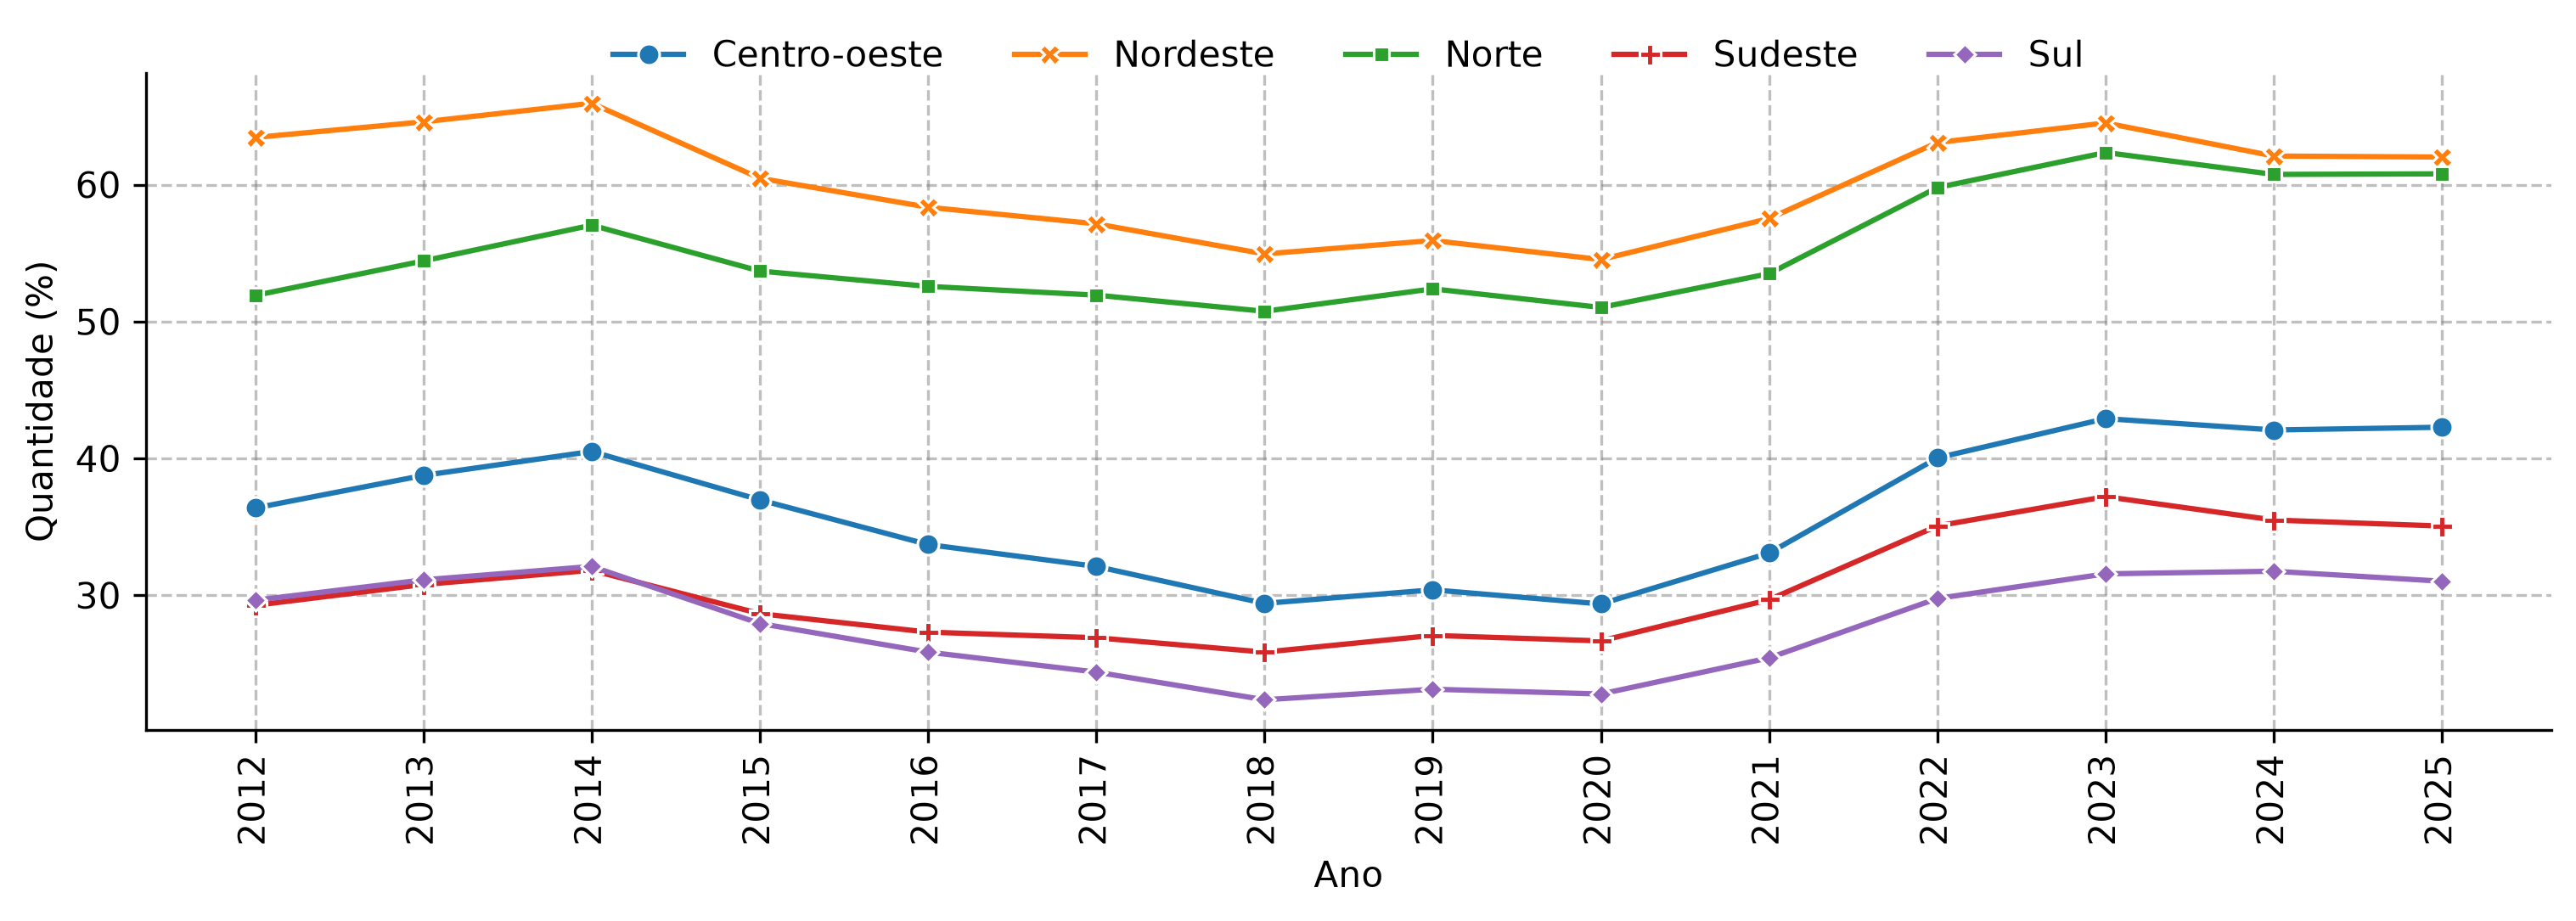

In [56]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_qtde_pessoas_por_ano_regiao,
    x='ano',
    y='pct',
    hue='regiao',
    style='regiao',
    markers=True,
    errorbar=None,
    dashes=False,
    ax=ax
)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Quantidade (%)')
ax.set_xlabel('Ano')
ax.set_xticks(anos, labels=anos, rotation=90)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=5, frameon=False)

fig.savefig('pessoas_no_cadunico_por_regiao', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
nao_ufs = list(chain(['Brasil'], regioes))
print(nao_ufs)

['Brasil', 'Norte', 'Nordeste', 'Sul', 'Sudeste', 'Centro-Oeste']


In [58]:
df_populacao_ufs = (
    df_populacao.query('LOCAL not in @nao_ufs and SEXO == "Ambos"')
    .drop(columns=['IDADE', 'SEXO', 'CÓD.', 'SIGLA'])
    .melt(
        id_vars='LOCAL',
        value_vars=[str(ano) for ano in range(2012, 2026)],
        var_name='ano',
        value_name='populacao'
    )
    .assign(ano=lambda x: pd.to_numeric(x['ano'], downcast='integer'))
    .rename(columns={
        'LOCAL': 'uf'
    })
    .groupby(['ano', 'uf'])
    .agg('sum')
    .sort_values(by=['ano', 'uf'])
    .reset_index()
    .assign(populacao_1e6 = lambda x: x['populacao'] / 1e6)
)


In [59]:
df_populacao_ufs.head()

,ano,uf,populacao,populacao_1e6
0,2012,Acre,791681,0.791681
1,2012,Alagoas,3152317,3.152317
2,2012,Amapá,711828,0.711828
3,2012,Amazonas,3673149,3.673149
4,2012,Bahia,14292856,14.292856


In [60]:
len(df_populacao_ufs['uf'].unique())

27

In [61]:
df_qtde_pessoas_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,uf,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,DF,Distrito Federal,804338,0.804338
1,2012,Pessoas,Centro-oeste,GO,Goiás,2331853,2.331853
2,2012,Pessoas,Centro-oeste,MS,Mato Grosso do Sul,989919,0.989919
3,2012,Pessoas,Centro-oeste,MT,Mato Grosso,1252738,1.252738
4,2012,Pessoas,Nordeste,AL,Alagoas,2055315,2.055315


In [62]:
df_qtde_pessoas_por_ano_regiao_uf = pd.merge(
    df_qtde_pessoas_por_ano_regiao_uf,
    df_populacao_ufs,
    on=['uf', 'ano']
)

In [63]:
df_qtde_pessoas_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,uf,qtde,qtde_1e6,populacao,populacao_1e6
0,2012,Pessoas,Centro-oeste,DF,Distrito Federal,804338,0.804338,2702947,2.702947
1,2012,Pessoas,Centro-oeste,GO,Goiás,2331853,2.331853,6351217,6.351217
2,2012,Pessoas,Centro-oeste,MS,Mato Grosso do Sul,989919,0.989919,2552390,2.552390
3,2012,Pessoas,Centro-oeste,MT,Mato Grosso,1252738,1.252738,3176859,3.176859
4,2012,Pessoas,Nordeste,AL,Alagoas,2055315,2.055315,3152317,3.152317


In [64]:
df_qtde_pessoas_por_ano_regiao_uf = (
    df_qtde_pessoas_por_ano_regiao_uf
        .assign(pct = lambda x: ((x['qtde'] / x['populacao']) * 100).round(2))
)

In [65]:
df_qtde_pessoas_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,uf,qtde,qtde_1e6,populacao,populacao_1e6,pct
0,2012,Pessoas,Centro-oeste,DF,Distrito Federal,804338,0.804338,2702947,2.702947,29.76
1,2012,Pessoas,Centro-oeste,GO,Goiás,2331853,2.331853,6351217,6.351217,36.72
2,2012,Pessoas,Centro-oeste,MS,Mato Grosso do Sul,989919,0.989919,2552390,2.552390,38.78
3,2012,Pessoas,Centro-oeste,MT,Mato Grosso,1252738,1.252738,3176859,3.176859,39.43
4,2012,Pessoas,Nordeste,AL,Alagoas,2055315,2.055315,3152317,3.152317,65.20


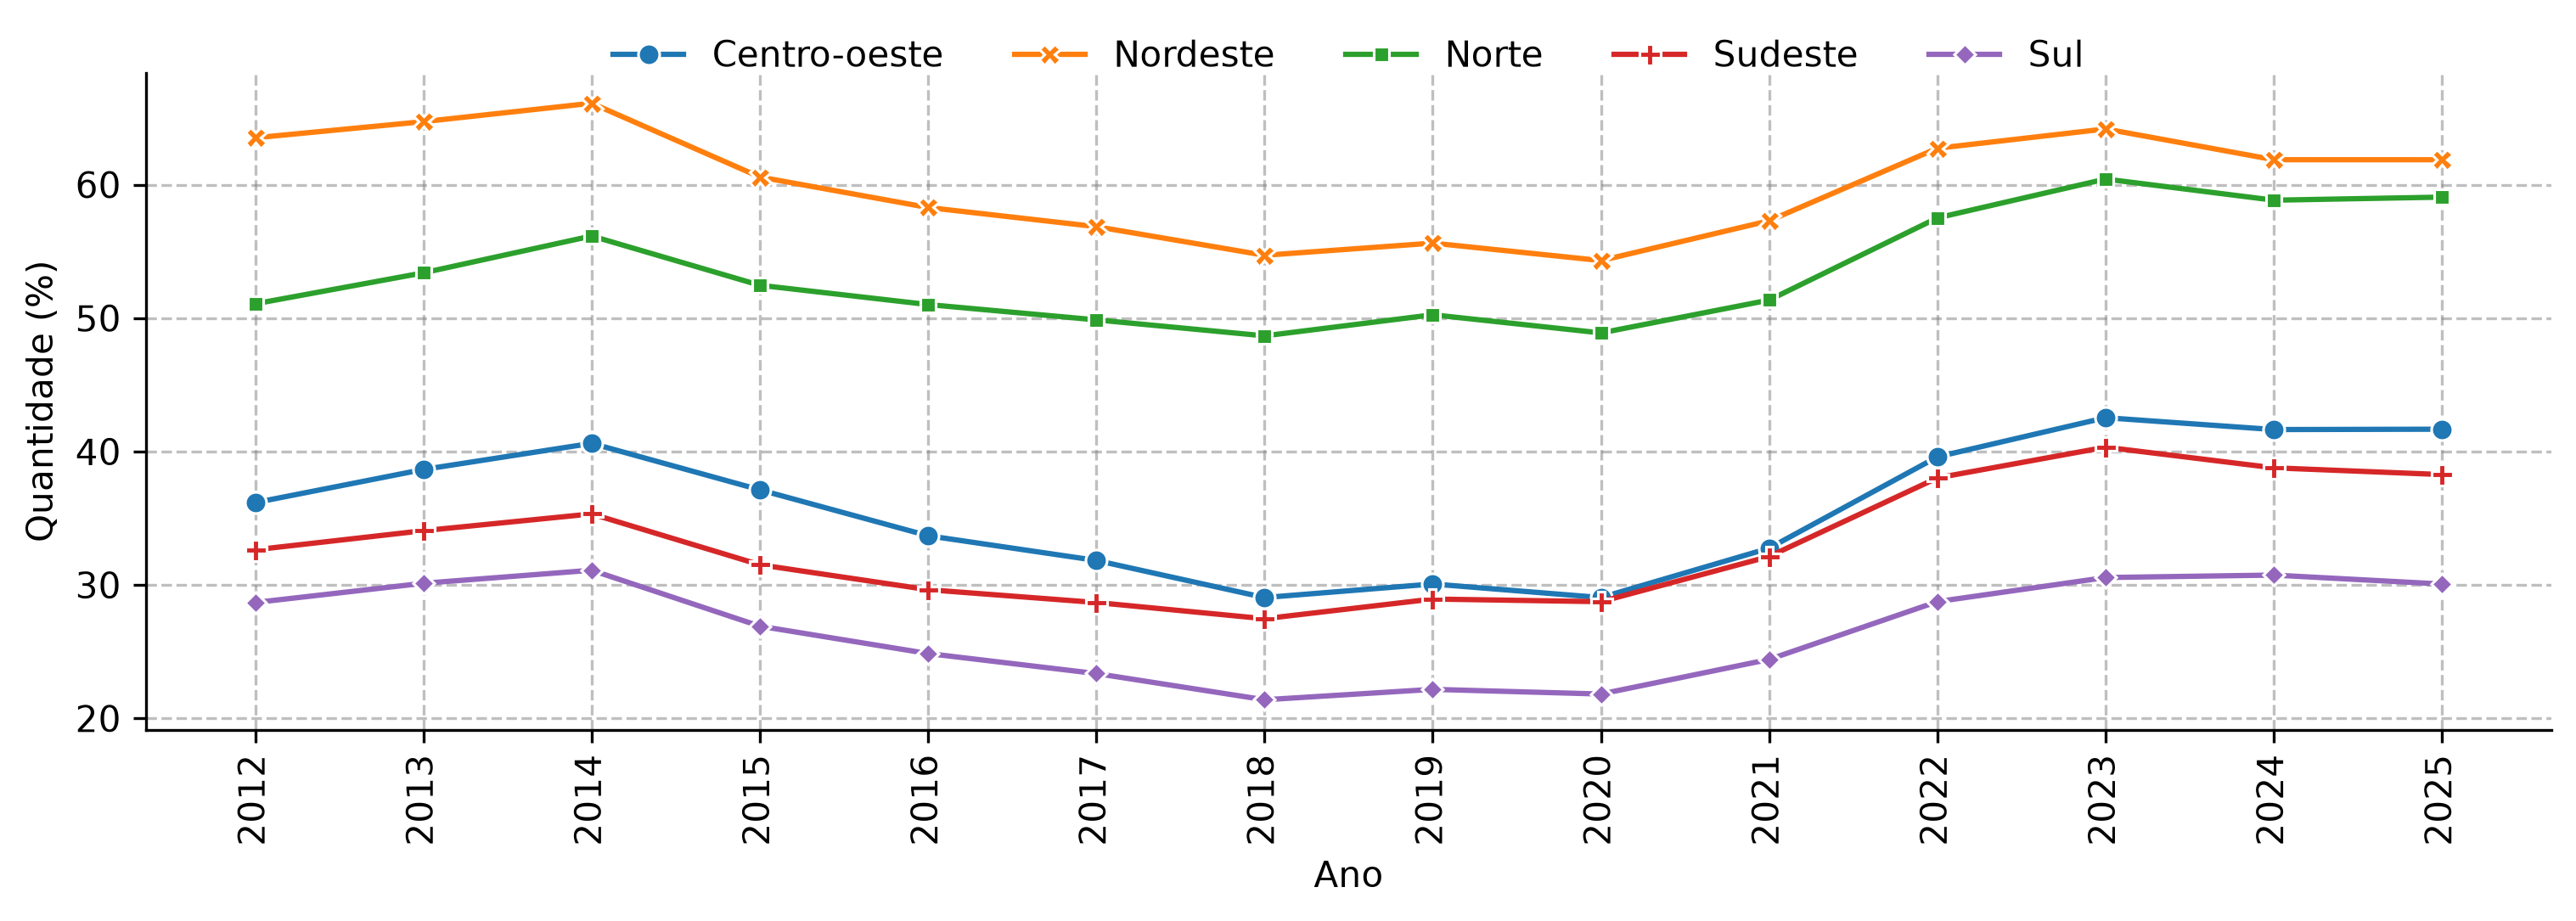

In [66]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_qtde_pessoas_por_ano_regiao_uf,
    x='ano',
    y='pct',
    hue='regiao',
    style='regiao',
    markers=True,
    errorbar=None,
    dashes=False,
    ax=ax
)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Quantidade (%)')
ax.set_xlabel('Ano')
ax.set_xticks(anos, labels=anos, rotation=90)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=9, frameon=False)

fig.savefig('pessoas_no_cadunico_por_ufs_nas_regioes', dpi=300, bbox_inches='tight')
plt.show()